# MyExperiences - Schedule Adherence Analysis

Two-arm study (Arm 1 Supported, Arm 2 Unsupported) of adaptive symptom monitoring. This notebook loads the survey, enrollment, and Oura wearable data; characterizes the baseline sample by arm; computes per-participant adherence for each study activity; and compares adherence between arms and over time.

## Setup and Data Loading

Load survey CSVs, enrollment rosters (Arm 1 = Supported, Arm 2 = Unsupported), and Oura streams; merge enrollment metadata; and add the `study_day` (1-indexed) and `daysSince` (0-indexed) study-time columns.

In [1]:
# Native libraries
import os
import math
# Essential Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy import stats
import seaborn as sns
import datetime as dt
import ast
import plotly.express as px
import scipy
from datetime import date, timedelta
import statsmodels.api as sm
import statsmodels.formula.api as smf
import json
import os
import ast
import csv
import io
from io import StringIO, BytesIO, TextIOWrapper
import gzip
from datetime import datetime, date

# Root directory for the raw study data (survey CSVs, Oura streams, enrollment rosters).
# Override with the MYEXP_DATA_DIR environment variable; defaults to the data-wave location.
DATA_DIR = os.environ.get("MYEXP_DATA_DIR", "/Volumes/T9/MyExperiences/final_wave_5_12_25")


In [2]:
# List of CSV files in the directory
csv_files = [
    "acquisition_source_feedback.csv",
    "adaptive_schedule_configuration.csv",
    "alcohol_habits.csv",
    "anxiety_questionnaire.csv",
    "childhood_experiences_questionnaire.csv",
    "consent_agreement.csv",
    "demographics_questionnaire.csv",
    "depression_questionnaire.csv",
    "emotional_bias_test.csv",
    "emotional_distress_questionnaire.csv",
    "emotional_support_questionnaire.csv",
    "fatigue_questionnaire.csv",
    "generalized_anxiety_questionnaire.csv",
    "healthcare_utilization_questionnaire.csv",
    "health_history_questionnaire.csv",
    "i've_noticed_questionnaire.csv",
    "lifestyle_questionnaire.csv",
    "lifestyle_survey.csv",
    "mania_questionnaire.csv",
    "medications_baseline.csv",
    "medications.csv",
    "menstrual_cycle_tracking.csv",
    "mindfulness_questionnaire.csv",
    "momentary_assessment.csv",
    "mood_disorder_questionnaire.csv",
    "oura_authorization_task.csv",
    "owned_devices_survey.csv",
    "personality_questionnaire.csv",
    "prodromal_questionnaire.csv",
    "psychomotor_vigilance_test.csv",
    "ptsd_questionnaire.csv",
    "quality_of_life_questionnaire.csv",
    "questionnaire_definitions_2025-05-11.csv",
    "questionnaire_random_schedules_2025-05-11.csv",
    "questionnaire_responses_2025-05-11.csv",
    "questionnaire_schedules_2025-05-11.csv",
    "self-reported_psychiatric_diagnosis.csv",
    "sleep_questionnaire.csv",
    "stress_questionnaire.csv",
    "substance_use.csv",
    "symptom_survey.csv",
    "trauma_questionnaire.csv",
    "video_diary_task.csv"
]

# Dictionary to store dataframes
df_dict = {}

# Loop through the CSV files and read them into dataframes with df_ prefix
for file in csv_files:
    df_name = 'df_' + file.split('.')[0]  # Create dataframe name
    # If the name has a '-' replace with _
    df_name = df_name.replace('-', '_')
    df_dict[df_name] = pd.read_csv(os.path.join(DATA_DIR, 'survey', file))
    globals()[df_name] = df_dict[df_name]  # Set the dataframe to a global variable

<cell>:56: DtypeWarning: Columns (0: question_id) have mixed types. Specify dtype option on import or set low_memory=False.


In [3]:
df_enrollment_unsupported = pd.read_csv(os.path.join(DATA_DIR, 'ARM2FINAL.csv'))
df_enrollment_supported = pd.read_csv(os.path.join(DATA_DIR, 'ARM1FINAL.csv'))

df_enrollment_unsupported.rename(columns={'4YAM Enroll Date': '4YAM Enroll'}, inplace=True)
df_enrollment_supported.rename(columns={'4YAM Enroll Date': '4YAM Enroll'}, inplace=True)

df_enrollment_unsupported.rename(columns={'MindMed ID': 'mm_id'}, inplace=True)
df_enrollment_supported.rename(columns={'MindMed ID': 'mm_id'}, inplace=True)

df_enrollment_supported['4YAM Enroll'] = pd.to_datetime(df_enrollment_supported['4YAM Enroll']).dt.date
df_enrollment_unsupported['4YAM Enroll'] = pd.to_datetime(df_enrollment_unsupported['4YAM Enroll']).dt.date
df_enrollment = pd.concat([df_enrollment_supported, df_enrollment_unsupported], ignore_index=True)

<cell>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


In [4]:
df_activity = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_activity.csv'))
df_activity['date'] = pd.to_datetime(df_activity.summary_date).dt.date

df_sleep = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_sleep.csv'))
df_sleep['date'] = pd.to_datetime(df_sleep.summary_date).dt.date

def secToTime(sec):
    return dt.timedelta(seconds =sec)

df_sleep['duration_time'] = df_sleep['duration'].apply(lambda x: x if pd.isnull(x) else secToTime(x))
df_sleep['duration_min'] = df_sleep['duration'].apply(lambda x: x if pd.isnull(x) else x/60)


df_readiness = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_readiness.csv'))
df_readiness['date'] = pd.to_datetime(df_readiness.summary_date).dt.date
df_hr = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_heartrate.csv'))
df_hr['date'] = pd.to_datetime(df_hr.Date).dt.date
df_sleepsum = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_sleep_summary.csv'), dtype={'movement_30_sec': str, 'sleep_phase_5_min': str})
df_sleepsum['date'] = pd.to_datetime(df_sleepsum.Date).dt.date
df_spo2 = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_spo2.csv'))
df_spo2['date'] = pd.to_datetime(df_spo2.Date).dt.date

In [5]:
# Merge 'df_sleep' and 'df_enrollment' on 'UserID'
df_sleep = pd.merge(df_sleep, df_enrollment[['mm_id', '4YAM Enroll', 'Oura Start', '4YAM End', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_readiness = pd.merge(df_readiness, df_enrollment[['mm_id', '4YAM Enroll', 'Oura Start', '4YAM End', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_activity = pd.merge(df_activity, df_enrollment[['mm_id', '4YAM Enroll', 'Oura Start', '4YAM End', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_hr = pd.merge(df_hr, df_enrollment[['mm_id', '4YAM Enroll', '4YAM End', 'Oura Start', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_sleepsum = pd.merge(df_sleepsum, df_enrollment[['mm_id', '4YAM Enroll', 'Oura Start', '4YAM End', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_spo2 = pd.merge(df_spo2, df_enrollment[['mm_id', '4YAM Enroll', '4YAM End', 'Oura Start', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))

# Convert 'date' and '4YAM Enroll' to datetime if not already
df_sleep['date'] = pd.to_datetime(df_sleep['date'])
df_sleep['4YAM Enroll'] = pd.to_datetime(df_sleep['4YAM Enroll'])
df_sleep['4YAM End'] = pd.to_datetime(df_sleep['4YAM End'])
df_readiness['date'] = pd.to_datetime(df_readiness['date'])
df_readiness['4YAM Enroll'] = pd.to_datetime(df_readiness['4YAM Enroll'])
df_readiness['4YAM End'] = pd.to_datetime(df_readiness['4YAM End'])
df_activity['date'] = pd.to_datetime(df_activity['date'])
df_activity['4YAM Enroll'] = pd.to_datetime(df_activity['4YAM Enroll'])
df_activity['4YAM End'] = pd.to_datetime(df_activity['4YAM End'])
df_hr['date'] = pd.to_datetime(df_hr['date'])
df_hr['4YAM Enroll'] = pd.to_datetime(df_hr['4YAM Enroll'])
df_hr['4YAM End'] = pd.to_datetime(df_hr['4YAM End'])
df_sleepsum['date'] = pd.to_datetime(df_sleepsum['date'])
df_sleepsum['4YAM Enroll'] = pd.to_datetime(df_sleepsum['4YAM Enroll'])
df_sleepsum['4YAM End'] = pd.to_datetime(df_sleepsum['4YAM End'])
df_spo2['date'] = pd.to_datetime(df_spo2['date'])
df_spo2['4YAM Enroll'] = pd.to_datetime(df_spo2['4YAM Enroll'])
df_spo2['4YAM End'] = pd.to_datetime(df_spo2['4YAM End'])

# Calculate the difference in days and add as a new column
df_sleep['study_day'] = (df_sleep['date'] - df_sleep['4YAM Enroll']).dt.days + 1
df_readiness['study_day'] = (df_readiness['date'] - df_readiness['4YAM Enroll']).dt.days + 1
df_activity['study_day'] = (df_activity['date'] - df_activity['4YAM Enroll']).dt.days + 1
df_hr['study_day'] = (df_hr['date'] - df_hr['4YAM Enroll']).dt.days + 1
df_sleepsum['study_day'] = (df_sleepsum['date'] - df_sleepsum['4YAM Enroll']).dt.days + 1
df_spo2['study_day'] = (df_spo2['date'] - df_spo2['4YAM Enroll']).dt.days + 1

<cell>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:27: UserWarning: C

In [6]:
# Function to process each dataframe with date check

def process_dates_and_merge(df, enrollment_df):
    if 'date' not in df.columns:
        print('SKIP')
        return df  # Skip processing if 'date' column doesn't exist
    df['date'] = pd.to_datetime(df['date'])
    df = pd.merge(df, enrollment_df[['mm_id', '4YAM Enroll']], left_on='mm_id', right_on='mm_id', how='inner', suffixes=('', '_y'))
    df['4YAM Enroll'] = pd.to_datetime(df['4YAM Enroll'])
    df['daysSince'] = (df['date'] - df['4YAM Enroll']).dt.days
    return df

# Apply the function to each dataframe in df_dict
for key in df_dict:
    print(key)
    df_dict[key] = process_dates_and_merge(df_dict[key], df_enrollment)

df_acquisition_source_feedback
df_adaptive_schedule_configuration
df_alcohol_habits
df_anxiety_questionnaire
df_childhood_experiences_questionnaire
df_consent_agreement
df_demographics_questionnaire
df_depression_questionnaire
df_emotional_bias_test
df_emotional_distress_questionnaire
df_emotional_support_questionnaire
df_fatigue_questionnaire
df_generalized_anxiety_questionnaire
df_healthcare_utilization_questionnaire
df_health_history_questionnaire
df_i've_noticed_questionnaire
df_lifestyle_questionnaire
df_lifestyle_survey
df_mania_questionnaire
df_medications_baseline
df_medications
df_menstrual_cycle_tracking
df_mindfulness_questionnaire
df_momentary_assessment
df_mood_disorder_questionnaire
df_oura_authorization_task
df_owned_devices_survey
df_personality_questionnaire
df_prodromal_questionnaire
df_psychomotor_vigilance_test
df_ptsd_questionnaire
df_quality_of_life_questionnaire
df_questionnaire_definitions_2025_05_11
SKIP
df_questionnaire_random_schedules_2025_05_11
SKIP
df_ques

In [7]:
df_adaptive_schedule_configuration['response_dict'] = df_adaptive_schedule_configuration['response'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
response_cols = df_adaptive_schedule_configuration['response_dict'].apply(pd.Series)
df_adaptive_schedule_configuration = df_adaptive_schedule_configuration.join(response_cols).drop(columns=['response_dict'])

df_adaptive_schedule_configuration

      mm_id  response_id             questionnaire  ...    OASIS    PHQ-9  EMDISTRESS
0        18          361  FUXP01-ADAPTIVE-SCHEDULE  ...  monthly  monthly     monthly
1        18         5942  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly     monthly
2        18         7026  FUXP01-ADAPTIVE-SCHEDULE  ...  monthly  monthly     monthly
3        18         8981  FUXP01-ADAPTIVE-SCHEDULE  ...  monthly  monthly     monthly
4        18        11738  FUXP01-ADAPTIVE-SCHEDULE  ...  monthly  monthly     monthly
...     ...          ...                       ...  ...      ...      ...         ...
2365    547        87189  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly      weekly
2366    547        87451  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly      weekly
2367    547        87657  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly      weekly
2368    547        87862  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly      weekly
2369    547        88017  FUXP01-ADAPTIVE-SCHEDULE  ..

In [8]:
def calculateScore(df, question_id_list):
    # Empty dictionary to hold the results
    all_complete_days_scores = {}

    # Filter the dataframe to include only the specified question IDs
    df_filtered = df[df['question_id'].isin(question_id_list)].copy()

    # Group by 'mm_id' and 'date', then calculate totals for each group
    for (mm_id, date, study_day), group in df_filtered.groupby(['mm_id', 'date', 'study_day']):
        # Check if we have the right number of question_ids
        if group['question_id'].nunique() == len(question_id_list):
            # Ignore 'NA' values when calculating sum
            score = group['score'].apply(pd.to_numeric, errors='coerce').sum()
            if mm_id not in all_complete_days_scores:
                all_complete_days_scores[mm_id] = []
            all_complete_days_scores[mm_id].append({'date': date, 'total_score': score, 'study_day': study_day})
    return all_complete_days_scores

In [9]:
phq9_18 = calculateScore(df_depression_questionnaire, [1,2,3,4,5,6,7,8,9])

In [10]:
enrolled_ids = df_enrollment['mm_id'].unique()

for key in df_dict:
    if 'mm_id' not in df_dict[key].columns:
        print('SKIP')
        continue
    df_dict[key] = df_dict[key][df_dict[key]['mm_id'].isin(enrolled_ids)]

SKIP
SKIP
SKIP


In [11]:
arm1ID = df_enrollment_supported.mm_id.unique()
arm2ID = df_enrollment_unsupported.mm_id.unique()

In [12]:
arm1Demo = df_enrollment_supported
arm2Demo = df_enrollment_unsupported

# Baseline Sample Characteristics by Arm

Demographic and psychiatric-history comparisons between the Supported (Arm 1) and Unsupported (Arm 2) arms.

## Demographic Summary (Age, Race/Ethnicity, Education, Gender)

In [13]:
# Calculate and compare characteristics of participants between two groups

def extract_and_summarize(df, group_name):
    summary = {}
    
    # Extract age, which requires calculating from a relevant date information if available
    if 'CALCULATED AGE (Y)' in df.columns:
        summary['Age'] = df['CALCULATED AGE (Y)'].describe()
    
    # Extract and process ethnicity
    if 'RACE / ETHNICITY' in df.columns:
        summary['Ethnicity'] = df['RACE / ETHNICITY'].value_counts(normalize=True)
    
    # Extract education level
    if 'EDUCATION LEVEL REACHED' in df.columns:
        summary['Education'] = df['EDUCATION LEVEL REACHED'].value_counts(normalize=True)
    
    # Extract gender
    if 'GENDER' in df.columns:
        summary['Gender'] = df['GENDER'].value_counts(normalize=True)
    
    # Print summary
    print(f'Characteristics Summary for {group_name} Group:')
    for key, value in summary.items():
        print(f"\n{key}:")
        print(value)
    print("\n------------------\n")

# Assume the columns 'AGE', 'ETHNICITY', 'EDUCATION', and 'GENDER' exist in the arm1Demo and arm2Demo datasets.
extract_and_summarize(arm1Demo, 'Arm 1')
extract_and_summarize(arm2Demo, 'Arm 2')

Characteristics Summary for Arm 1 Group:

Age:
count    151.000000
mean      23.774834
std        7.022034
min       18.000000
25%       20.000000
50%       21.000000
75%       24.000000
max       55.000000
Name: CALCULATED AGE (Y), dtype: float64

Ethnicity:
RACE / ETHNICITY
WHITE                           0.768212
ASIAN                           0.099338
BLACK                           0.059603
MULTI-RACIAL                    0.026490
NATIVE / INDIGENOUS AMERICAN    0.013245
PNTS / UNK                      0.013245
OTHER (HISPANIC/LATINO)         0.013245
OTHER (MIDDLE EASTERN)          0.006623
Name: proportion, dtype: float64

Education:
EDUCATION LEVEL REACHED
SOME COLLEGE    0.642384
BACHELOR'S      0.218543
ASSOCIATE'S     0.086093
MASTER'S        0.046358
DOCTORATE       0.006623
Name: proportion, dtype: float64

Gender:
GENDER
FEMALE        0.781457
MALE          0.139073
NON-BINARY    0.072848
OTHER         0.006623
Name: proportion, dtype: float64

------------------

Charac

## Psychiatric History and Screening: Between-Arm Tests

In [14]:
mentalLists = ['MED HX:\n\nMOOD DISORDER', 'MED HX:\n\nANXIETY DISORDER',
       'MED HX:\n\nSCHIZOPHRENIA / OTHER PSYCHOTIC SPECTRUM DISORDER',
       'NO MED HX OF THESE DISORDERS REPORTED', 'POSITIVE SCREEN:\n\nMDQ',
       'POSITIVE SCREEN:\n\nPHQ-9', 'POSITIVE SCREEN:\n\nGAD-7',
       'POSITIVE SCREEN:\n\nPQ-B']

# Replace all NaN values in the listed columns with 'N' for both dataframes
for column in mentalLists:
    if column in arm1Demo.columns:
        arm1Demo[column] = arm1Demo[column].fillna('N')  # Ensure assignment back to the column
    if column in arm2Demo.columns:
        arm2Demo[column] = arm2Demo[column].fillna('N')  # Ensure assignment back to the column

In [15]:
from scipy.stats import chi2_contingency, fisher_exact
import pandas as pd

def statistical_testing_mental_columns(df1, df2, mental_columns):
    for column in mental_columns:
        if column in df1.columns and column in df2.columns:
            # Get value counts for each mental health column for both dataframes
            col_counts_df1 = df1[column].value_counts()
            col_counts_df2 = df2[column].value_counts()

            # Combine counts into a contingency table
            contingency_table = pd.concat([col_counts_df1, col_counts_df2], axis=1, keys=['Arm 1', 'Arm 2']).fillna(0)

            # Check expected frequencies to decide test
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            min_expected = expected.min()

            if min_expected < 5 and contingency_table.shape == (2, 2):
                # Use Fisher's exact test for 2x2 tables with low expected frequencies
                odds_ratio, p_value_fisher = fisher_exact(contingency_table.values.astype(int))
                print(f"Fisher's exact test for {column}: OR = {odds_ratio:.2f}, p-value = {p_value_fisher:.5f}  "
                      f"(min expected freq = {min_expected:.2f})")
            else:
                print(f"Chi-squared test for {column}: chi2 = {chi2:.2f}, p-value = {p_value:.5f}")

# Perform statistical testing on columns in mentalLists
statistical_testing_mental_columns(arm1Demo, arm2Demo, mentalLists)

Chi-squared test for MED HX:

MOOD DISORDER: chi2 = 0.01, p-value = 0.90833
Chi-squared test for MED HX:

ANXIETY DISORDER: chi2 = 3.52, p-value = 0.06082
Fisher's exact test for MED HX:

SCHIZOPHRENIA / OTHER PSYCHOTIC SPECTRUM DISORDER: OR = inf, p-value = 1.00000  (min expected freq = 0.50)
Chi-squared test for NO MED HX OF THESE DISORDERS REPORTED: chi2 = 3.22, p-value = 0.07279
Chi-squared test for POSITIVE SCREEN:

MDQ: chi2 = 8.31, p-value = 0.00395
Chi-squared test for POSITIVE SCREEN:

PHQ-9: chi2 = 1.61, p-value = 0.20432
Chi-squared test for POSITIVE SCREEN:

GAD-7: chi2 = 0.05, p-value = 0.81718
Chi-squared test for POSITIVE SCREEN:

PQ-B: chi2 = 2.47, p-value = 0.11615


In [16]:
from scipy.stats import chi2_contingency
import pandas as pd

def statistical_testing_mental_columns(df1, df2, mental_columns):
    for column in mental_columns:
        if column in df1.columns and column in df2.columns:
            # Get value counts for each mental health column for both dataframes
            col_counts_df1 = df1[column].value_counts()
            col_counts_df2 = df2[column].value_counts()
            
            # Calculate percentages
            col_pct_df1 = (col_counts_df1 / len(df1) * 100).round(1)
            col_pct_df2 = (col_counts_df2 / len(df2) * 100).round(1)

            # Combine counts into a contingency table
            contingency_table = pd.concat([col_counts_df1, col_counts_df2], axis=1, keys=['Arm 1', 'Arm 2']).fillna(0)

            # Perform chi-squared test
            chi2, p_value, _, _ = chi2_contingency(contingency_table)

            # Output results with counts and percentages
            print(f"\nResults for {column}:")
            print("Arm 1:")
            for val in col_counts_df1.index:
                n = col_counts_df1[val]
                pct = col_pct_df1[val]
                print(f"{val}: {n} ({pct}%)")
            
            print("\nArm 2:")
            for val in col_counts_df2.index:
                n = col_counts_df2[val]
                pct = col_pct_df2[val]
                print(f"{val}: {n} ({pct}%)")
            
            print(f"\nChi-squared test: chi2 = {chi2:.2f}, p-value = {p_value:.5f}")
            print("-" * 50)

# Perform statistical testing on columns in mentalLists
statistical_testing_mental_columns(arm1Demo, arm2Demo, mentalLists)


Results for MED HX:

MOOD DISORDER:
Arm 1:
N: 77 (51.0%)
Y: 74 (49.0%)

Arm 2:
N: 79 (52.3%)
Y: 72 (47.7%)

Chi-squared test: chi2 = 0.01, p-value = 0.90833
--------------------------------------------------

Results for MED HX:

ANXIETY DISORDER:
Arm 1:
Y: 114 (75.5%)
N: 37 (24.5%)

Arm 2:
Y: 128 (84.8%)
N: 23 (15.2%)

Chi-squared test: chi2 = 3.52, p-value = 0.06082
--------------------------------------------------

Results for MED HX:

SCHIZOPHRENIA / OTHER PSYCHOTIC SPECTRUM DISORDER:
Arm 1:
N: 151 (100.0%)

Arm 2:
N: 150 (99.3%)
Y: 1 (0.7%)

Chi-squared test: chi2 = 0.00, p-value = 1.00000
--------------------------------------------------

Results for NO MED HX OF THESE DISORDERS REPORTED:
Arm 1:
N: 123 (81.5%)
Y: 28 (18.5%)

Arm 2:
N: 135 (89.4%)
Y: 16 (10.6%)

Chi-squared test: chi2 = 3.22, p-value = 0.07279
--------------------------------------------------

Results for POSITIVE SCREEN:

MDQ:
Arm 1:
Y: 84 (55.6%)
N: 67 (44.4%)

Arm 2:
N: 93 (61.6%)
Y: 58 (38.4%)

Chi-squared

In [17]:
from scipy.stats import mannwhitneyu, chi2_contingency, shapiro
import numpy as np
import pandas as pd

def statistical_testing_group_differences(df1, df2):
    # Test for normality - Age
    age1 = df1['CALCULATED AGE (Y)'].dropna()
    age2 = df2['CALCULATED AGE (Y)'].dropna()
    stat1, p_normality1 = shapiro(age1)
    stat2, p_normality2 = shapiro(age2)
    print(f"Shapiro-Wilk Test for Age in Arm 1: statistic = {stat1:.2f}, p-value = {p_normality1:.5f}")
    print(f"Shapiro-Wilk Test for Age in Arm 2: statistic = {stat2:.2f}, p-value = {p_normality2:.5f}")

    # Conduct test for Age based on normality
    if p_normality1 < 0.05 or p_normality2 < 0.05:
        u_stat, p_value_age = mannwhitneyu(age1, age2)
        print(f"Mann-Whitney U test for Age: U-statistic = {u_stat:.2f}, p-value = {p_value_age:.5f}")
    else:
        t_stat, p_value_age = ttest_ind(age1, age2)
        print(f"T-test for Age: t-statistic = {t_stat:.2f}, p-value = {p_value_age:.5f}")

    # Conduct chi-squared test for Gender
    gender1 = df1['GENDER'].value_counts()
    gender2 = df2['GENDER'].value_counts()
    gender_table = pd.concat([gender1, gender2], axis=1, keys=['Arm 1', 'Arm 2']).fillna(0)
    chi2, p_value_gender, _, _ = chi2_contingency(gender_table)
    print(f"Chi-squared test for Gender: chi2 = {chi2:.2f}, p-value = {p_value_gender:.5f}")

    # Conduct chi-squared test for Ethnicity
    ethnicity1 = df1['RACE / ETHNICITY'].value_counts()
    ethnicity2 = df2['RACE / ETHNICITY'].value_counts()
    ethnicity_table = pd.concat([ethnicity1, ethnicity2], axis=1, keys=['Arm 1', 'Arm 2']).fillna(0)
    chi2, p_value_ethnicity, _, _ = chi2_contingency(ethnicity_table)
    print(f"Chi-squared test for Ethnicity: chi2 = {chi2:.2f}, p-value = {p_value_ethnicity:.5f}")

    # Conduct chi-squared test for Education Level
    # education1 = df1['EDUCATION LEVEL REACHED'].value_counts()
    # education2 = df2['EDUCATION LEVEL REACHED'].value_counts()
    # education_table = pd.concat([education1, education2], axis=1, keys=['Arm 1', 'Arm 2']).fillna(0)
    # chi2, p_value_education, _, _ = chi2_contingency(education_table)
    # print(f"Chi-squared test for Education Level: chi2 = {chi2:.2f}, p-value = {p_value_education:.5f}")

# Perform statistical testing between arm1Demo and arm2Demo
statistical_testing_group_differences(arm1Demo, arm2Demo)

Shapiro-Wilk Test for Age in Arm 1: statistic = 0.67, p-value = 0.00000
Shapiro-Wilk Test for Age in Arm 2: statistic = 0.66, p-value = 0.00000
Mann-Whitney U test for Age: U-statistic = 9956.50, p-value = 0.05490
Chi-squared test for Gender: chi2 = 0.56, p-value = 0.90441
Chi-squared test for Ethnicity: chi2 = 6.06, p-value = 0.53220


In [18]:
arm2Demo["RACE / ETHNICITY"].value_counts()

RACE / ETHNICITY
WHITE                           108
ASIAN                            11
BLACK                            10
OTHER (HISPANIC/LATINO)           6
PNTS / UNK                        6
MULTI-RACIAL                      5
OTHER (MIDDLE EASTERN)            3
NATIVE / INDIGENOUS AMERICAN      2
Name: count, dtype: int64

## Race / Ethnicity: Category Consolidation and Between-Arm Test

Small-count categories (Multi-Racial, Native/Indigenous, Hispanic/Latino, Middle Eastern, PNTS/UNK) are consolidated into "Other/Multiple" so that all chi-square expected cell counts are >= 5.

In [19]:
from scipy.stats import chi2_contingency, mannwhitneyu
import numpy as np
import pandas as pd

# Consolidate ethnicity categories
def collapse_ethnicity(eth):
    if pd.isna(eth):
        return 'Other/Multiple'
    eth = str(eth).strip().upper()
    if eth == 'WHITE':
        return 'White'
    elif eth == 'ASIAN':
        return 'Asian'
    elif eth == 'BLACK':
        return 'Black'
    else:
        return 'Other/Multiple'

arm1Demo['ethnicity_collapsed'] = arm1Demo['RACE / ETHNICITY'].apply(collapse_ethnicity)
arm2Demo['ethnicity_collapsed'] = arm2Demo['RACE / ETHNICITY'].apply(collapse_ethnicity)

# Verify chi-square assumptions are now met
arm1Demo['arm'] = 'Arm 1'
arm2Demo['arm'] = 'Arm 2'
combined_eth = pd.concat([arm1Demo[['arm', 'ethnicity_collapsed']],
                          arm2Demo[['arm', 'ethnicity_collapsed']]]).reset_index(drop=True)

contingency = pd.crosstab(combined_eth['arm'], combined_eth['ethnicity_collapsed'])
contingency_pct = pd.crosstab(combined_eth['arm'], combined_eth['ethnicity_collapsed'],
                              normalize='index') * 100

# Combine counts and percentages into a single display table
contingency_display = contingency.copy().astype(str)
for col in contingency.columns:
    contingency_display[col] = (
        contingency[col].astype(str) + ' (' + contingency_pct[col].round(1).astype(str) + '%)'
    )

print("=" * 80)
print("COLLAPSED ETHNICITY — Contingency Table (count and row %)")
print("=" * 80)
print(contingency_display)

chi2, p_val, dof, expected = chi2_contingency(contingency)

print("\nExpected Frequencies:")
print(pd.DataFrame(expected, index=contingency.index,
                   columns=contingency.columns).round(2))

min_exp = expected.min()
cells_below_5 = (expected < 5).sum()
total_cells = expected.size
print(f"\nMinimum expected frequency: {min_exp:.2f}")
print(f"Cells with expected freq < 5: {cells_below_5}/{total_cells} "
      f"({cells_below_5/total_cells*100:.1f}%)")

if min_exp >= 5:
    print(f"\nChi-squared assumptions MET")
else:
    print(f"\nChi-squared assumptions VIOLATED — consider further consolidation")

print(f"\nChi-squared test (collapsed ethnicity):")
print(f"  chi2 = {chi2:.4f}, df = {dof}, p-value = {p_val:.5f}")
if p_val < 0.05:
    print("  => Significant difference in ethnicity distribution between arms (p < 0.05)")
else:
    print("  => No significant difference in ethnicity distribution between arms")

COLLAPSED ETHNICITY — Contingency Table (count and row %)
ethnicity_collapsed      Asian      Black Other/Multiple        White
arm                                                                  
Arm 1                15 (9.9%)   9 (6.0%)      11 (7.3%)  116 (76.8%)
Arm 2                11 (7.3%)  10 (6.6%)     22 (14.6%)  108 (71.5%)

Expected Frequencies:
ethnicity_collapsed  Asian  Black  Other/Multiple  White
arm                                                     
Arm 1                 13.0    9.5            16.5  112.0
Arm 2                 13.0    9.5            16.5  112.0

Minimum expected frequency: 9.50
Cells with expected freq < 5: 0/8 (0.0%)

Chi-squared assumptions MET

Chi-squared test (collapsed ethnicity):
  chi2 = 4.6204, df = 3, p-value = 0.20180
  => No significant difference in ethnicity distribution between arms


## Education: Category Consolidation and Between-Arm Test

In [20]:
arm1Demo['EDUCATION LEVEL REACHED'].value_counts()

EDUCATION LEVEL REACHED
SOME COLLEGE    97
BACHELOR'S      33
ASSOCIATE'S     13
MASTER'S         7
DOCTORATE        1
Name: count, dtype: int64

In [21]:
arm2Demo["EDUCATION LEVEL REACHED"].value_counts()

EDUCATION LEVEL REACHED
SOME COLLEGE         62
BACHELOR'S           59
MASTER'S             13
ASSOCIATE'S           6
PROFESSIONAL (MD)     5
DOCTORATE             2
DNF HIGH SCHOOL       2
PNTS / UNK            2
Name: count, dtype: int64

In [22]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
import numpy as np

print("="*80)
print("Uncollapsed education categories")
print("="*80)

# Create arm labels
arm1Demo['arm'] = 'Arm 1'
arm2Demo['arm'] = 'Arm 2'

# Combine the dataframes
combined_df = pd.concat([arm1Demo, arm2Demo], ignore_index=True)

# Create contingency table with original education categories
contingency_original = pd.crosstab(combined_df['arm'], combined_df['EDUCATION LEVEL REACHED'])

print("\nOriginal Contingency Table:")
print(contingency_original)
print("\nPercentages by Arm:")
percentage_original = pd.crosstab(combined_df['arm'], combined_df['EDUCATION LEVEL REACHED'], normalize='index') * 100
print(percentage_original.round(1))

# Check expected frequencies
chi2_orig, p_orig, dof_orig, expected_orig = chi2_contingency(contingency_original)

print("\nExpected Frequencies:")
expected_df_orig = pd.DataFrame(expected_orig, index=contingency_original.index, columns=contingency_original.columns)
print(expected_df_orig.round(2))

min_expected_orig = expected_orig.min()
print(f"\nMinimum expected frequency: {min_expected_orig:.2f}")

# Count cells with expected frequency < 5
cells_below_5 = (expected_orig < 5).sum()
total_cells = expected_orig.size
percent_below_5 = (cells_below_5 / total_cells) * 100

print(f"Cells with expected frequency < 5: {cells_below_5}/{total_cells} ({percent_below_5:.1f}%)")

if min_expected_orig >= 5:
    print(f"\nChi-squared assumption met")
    print(f"\nChi-squared test results:")
    print(f"Chi-squared statistic: {chi2_orig:.2f}")
    print(f"Degrees of freedom: {dof_orig}")
    print(f"P-value: {p_orig:.4f}")
else:
    print(f"\nChi-squared assumption violated (rule of thumb: <20% of cells should have expected freq < 5)")
    print("\nFor uncollapsed data with sparse cells, Fisher-Freeman-Halton exact test is recommended.")
    print("However, scipy doesn't have built-in Fisher-Freeman-Halton test.")
    print("\nOptions:")
    print("1. Use R's fisher.test() via rpy2")
    print("2. Use Monte Carlo simulation")
    print("3. Collapse categories (see the collapsed analysis below)")
    
    # Show chi-squared anyway with warning
    print(f"\nChi-squared test (interpret with caution due to violated assumptions):")
    print(f"Chi-squared statistic: {chi2_orig:.2f}")
    print(f"P-value: {p_orig:.4f}")

print("\n" + "="*80)
print("Collapsed education categories")
print("="*80)

# Define the function to collapse education levels
def collapse_education(ed):
    if pd.isna(ed):
        return 'PNTS / UNK'
    
    ed_str = str(ed).upper().strip()
    
    # PNTS / UNK category
    if ed_str == 'PNTS / UNK':
        return 'PNTS / UNK'
    
    # HIGH SCHOOL OR BELOW
    elif ed_str in ['DNF HIGH SCHOOL', 'HIGH SCHOOL', 'HS', 'HIGH SCHOOL DIPLOMA']:
        return 'HIGH SCHOOL OR BELOW'
    
    # SOME COLLEGE / ASSOCIATE
    elif ed_str in ['SOME COLLEGE', "ASSOCIATE'S", 'ASSOCIATES']:
        return 'SOME COLLEGE / ASSOCIATE'
    
    # BACHELOR'S
    elif ed_str == "BACHELOR'S":
        return "BACHELOR'S"
    
    # GRADUATE / PROFESSIONAL
    elif ed_str in ["MASTER'S", 'DOCTORATE', 'PROFESSIONAL', 'PROFESSIONAL (MD)']:
        return 'GRADUATE / PROFESSIONAL'
    
    else:
        return 'PNTS / UNK'

# Apply the collapse function
arm1Demo['education_collapsed'] = arm1Demo['EDUCATION LEVEL REACHED'].apply(collapse_education)
arm2Demo['education_collapsed'] = arm2Demo['EDUCATION LEVEL REACHED'].apply(collapse_education)

# Update combined dataframe
combined_df = pd.concat([arm1Demo[['arm', 'education_collapsed']], 
                         arm2Demo[['arm', 'education_collapsed']]], ignore_index=True)

# Create contingency table with collapsed categories
contingency_collapsed = pd.crosstab(combined_df['arm'], combined_df['education_collapsed'])

print("\nCollapsed Contingency Table:")
print(contingency_collapsed)
print("\nPercentages by Arm:")
percentage_collapsed = pd.crosstab(combined_df['arm'], combined_df['education_collapsed'], normalize='index') * 100
print(percentage_collapsed.round(1))

# Check expected frequencies
chi2_coll, p_coll, dof_coll, expected_coll = chi2_contingency(contingency_collapsed)

print("\nExpected Frequencies:")
expected_df_coll = pd.DataFrame(expected_coll, index=contingency_collapsed.index, columns=contingency_collapsed.columns)
print(expected_df_coll.round(2))

min_expected_coll = expected_coll.min()
print(f"\nMinimum expected frequency: {min_expected_coll:.2f}")

# Count cells with expected frequency < 5
cells_below_5_coll = (expected_coll < 5).sum()
total_cells_coll = expected_coll.size
percent_below_5_coll = (cells_below_5_coll / total_cells_coll) * 100

print(f"Cells with expected frequency < 5: {cells_below_5_coll}/{total_cells_coll} ({percent_below_5_coll:.1f}%)")

if min_expected_coll >= 5 and percent_below_5_coll < 20:
    print(f"\nChi-squared assumptions met")
    print(f"\nChi-squared test results:")
    print(f"Chi-squared statistic: {chi2_coll:.2f}")
    print(f"Degrees of freedom: {dof_coll}")
    print(f"P-value: {p_coll:.4f}")
    
    if p_coll < 0.05:
        print("\n** Significant difference in education distribution between arms (p < 0.05)")
    else:
        print("\n** No significant difference in education distribution between arms (p ≥ 0.05)")
else:
    print(f"\nChi-squared assumption still violated")
    print("\nRecommendation: Further collapse categories or use exact test")

print("\n" + "="*80)
print("Summary:")
print("="*80)
print("The collapsed-category test is used because:")
print("1. It meets chi-squared test assumptions")
print("2. It reduces categories based on meaningful educational attainment levels")
print("3. The results are more statistically valid and easier to interpret")
print("\nFisher-Freeman-Halton would preserve original categories but requires")
print("external tools (R) or complex implementation in Python.")

Uncollapsed education categories

Original Contingency Table:
EDUCATION LEVEL REACHED  ASSOCIATE'S  ...  SOME COLLEGE
arm                                   ...              
Arm 1                             13  ...            97
Arm 2                              6  ...            62

[2 rows x 8 columns]

Percentages by Arm:
EDUCATION LEVEL REACHED  ASSOCIATE'S  ...  SOME COLLEGE
arm                                   ...              
Arm 1                            8.6  ...          64.2
Arm 2                            4.0  ...          41.1

[2 rows x 8 columns]

Expected Frequencies:
EDUCATION LEVEL REACHED  ASSOCIATE'S  ...  SOME COLLEGE
arm                                   ...              
Arm 1                            9.5  ...          79.5
Arm 2                            9.5  ...          79.5

[2 rows x 8 columns]

Minimum expected frequency: 1.00
Cells with expected frequency < 5: 8/16 (50.0%)

Chi-squared assumption violated (rule of thumb: <20% of cells should have

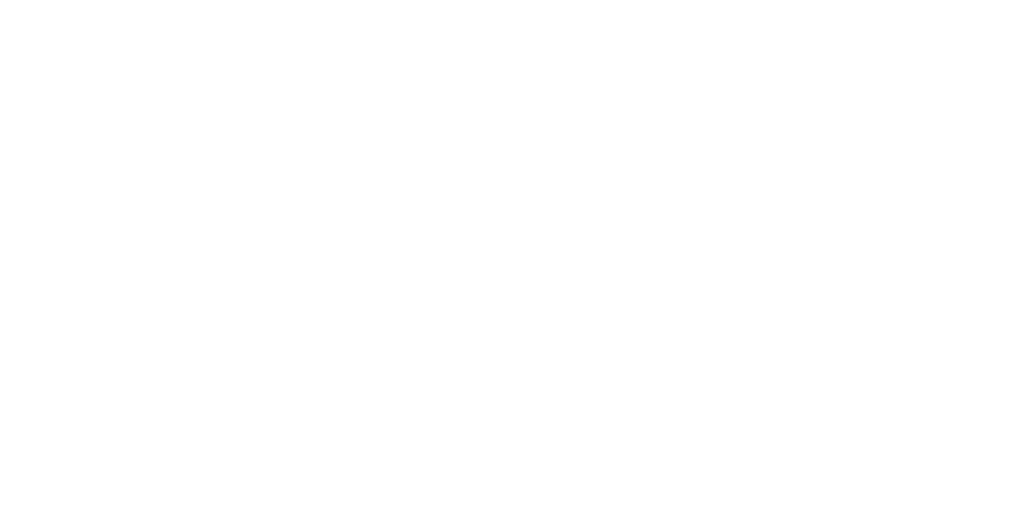

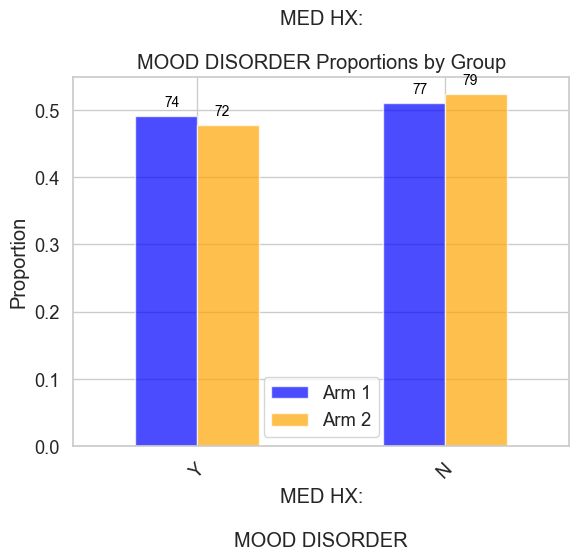

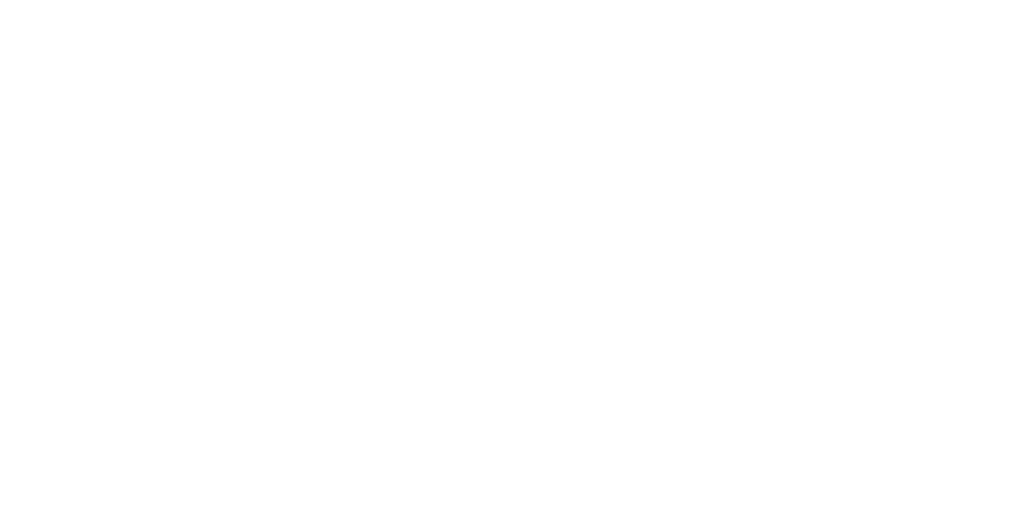

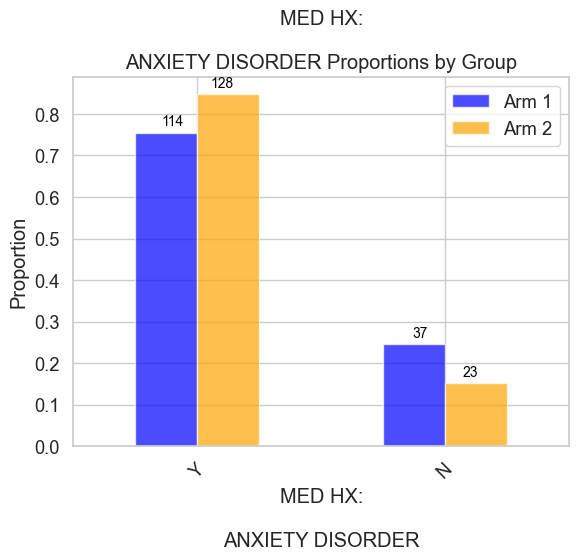

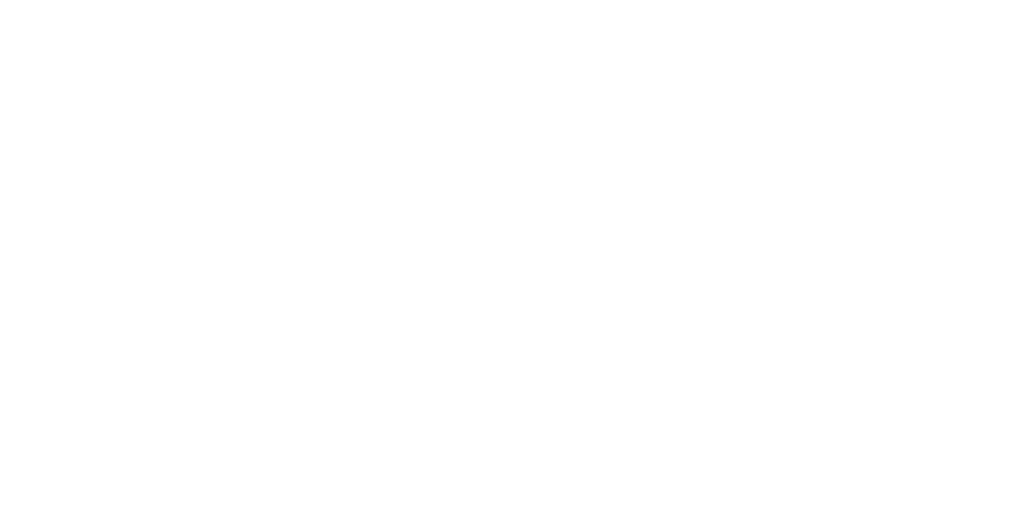

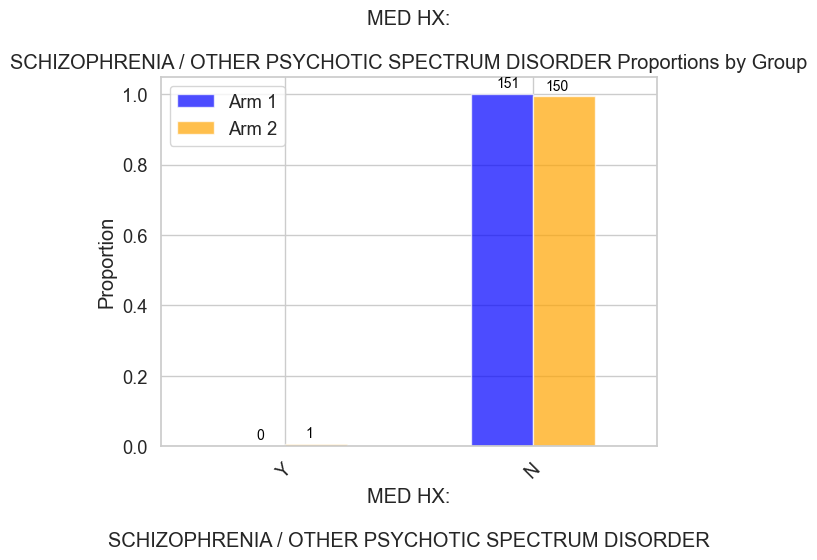

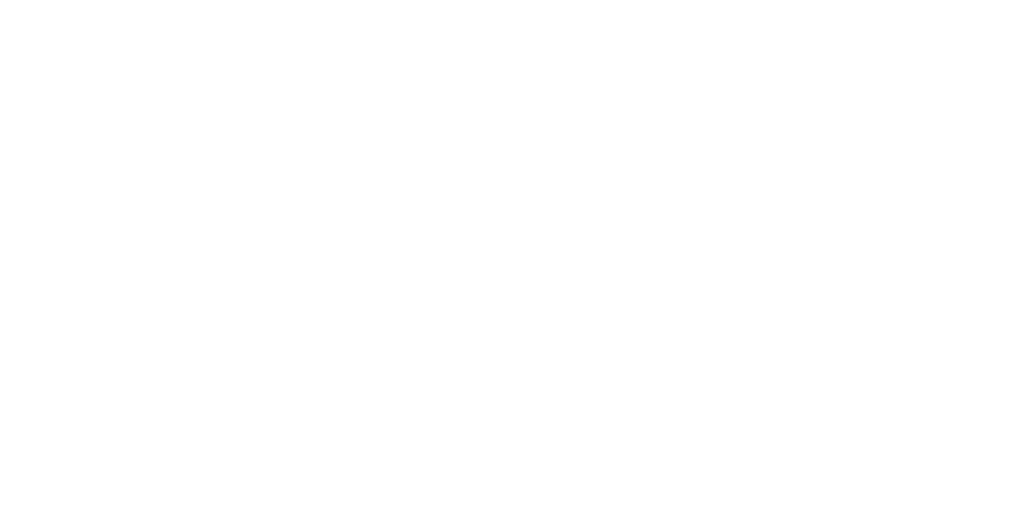

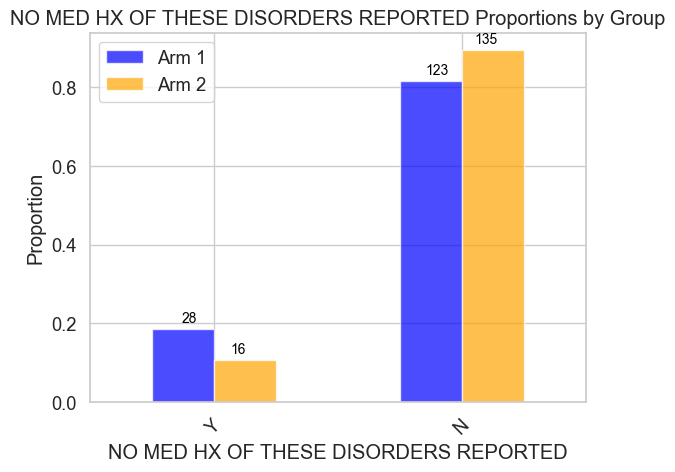

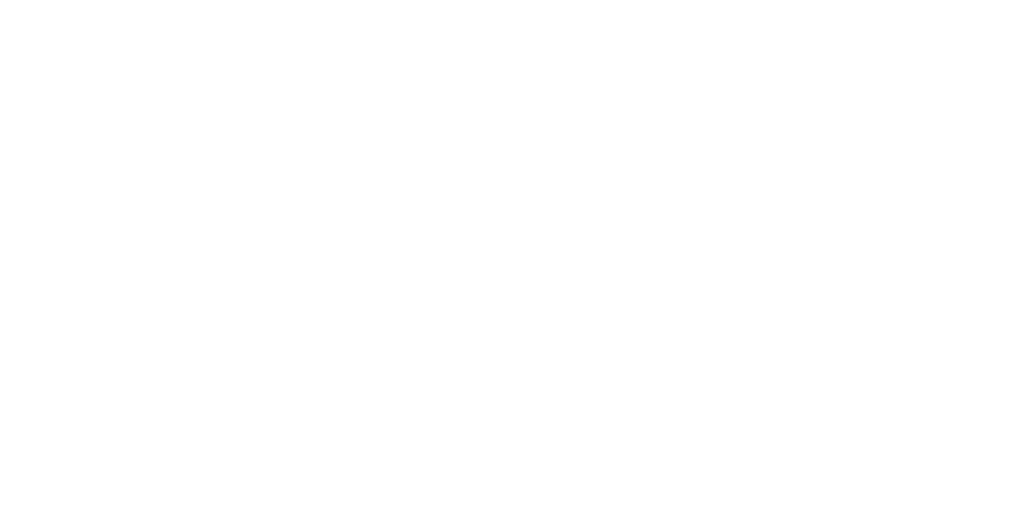

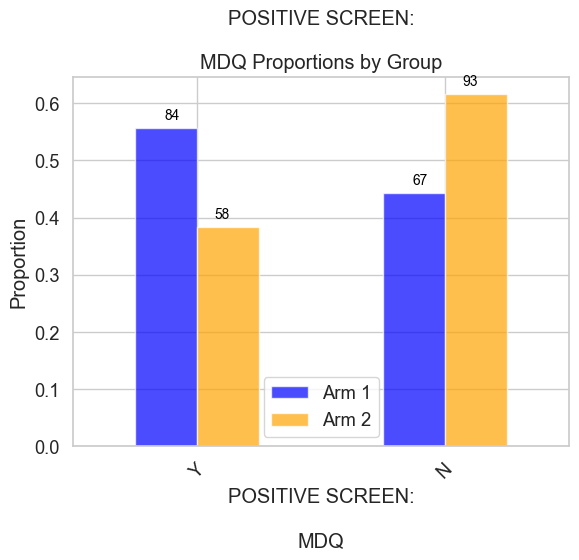

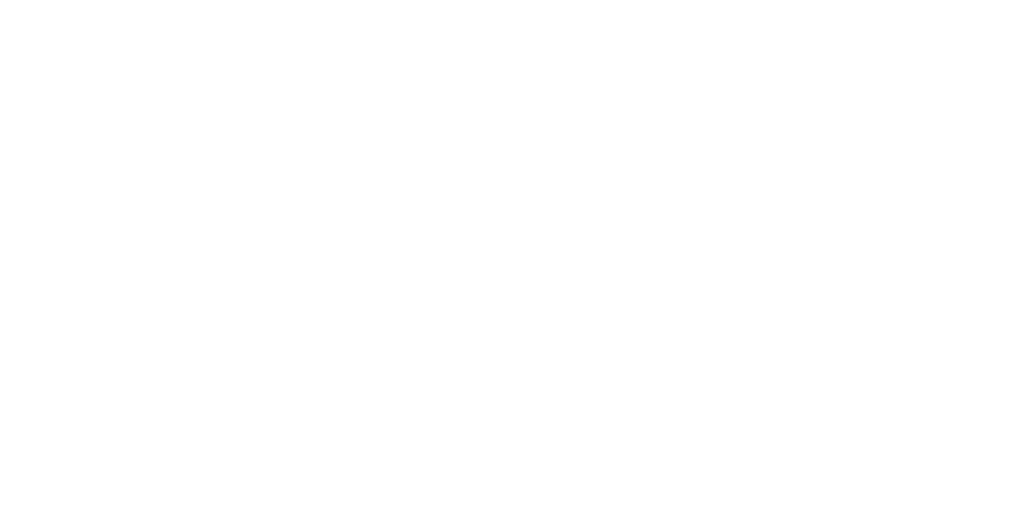

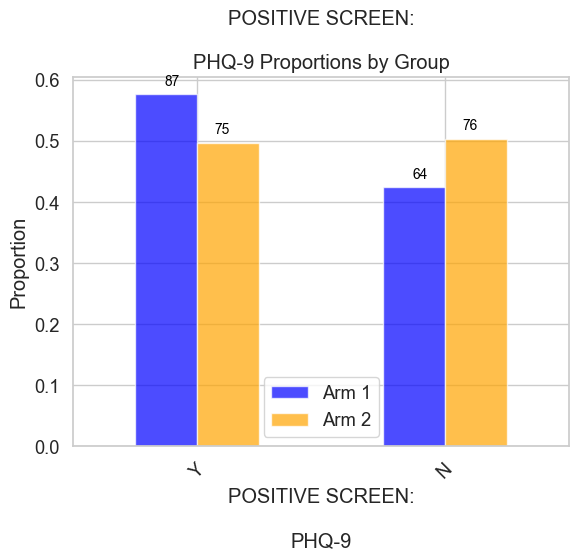

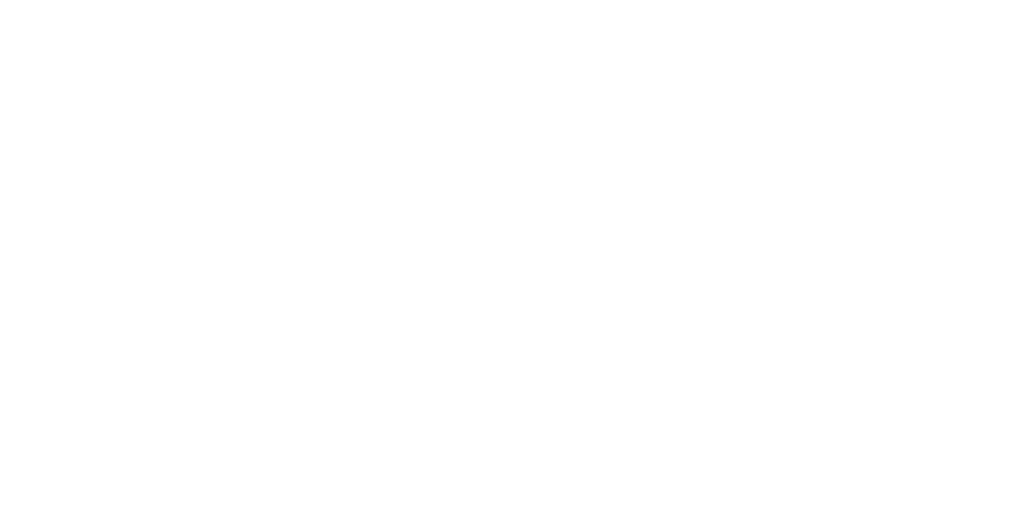

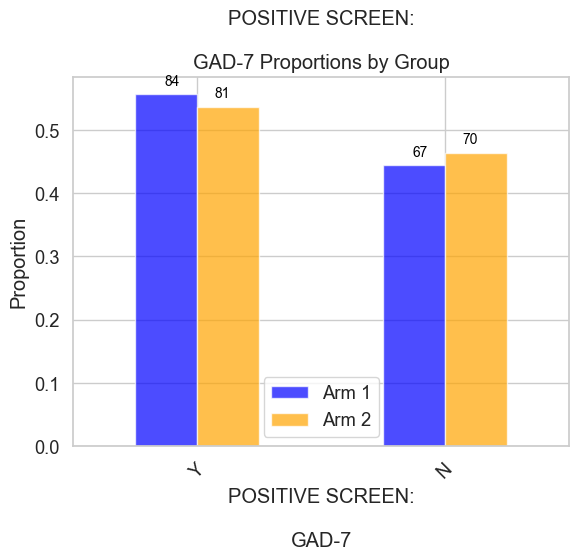

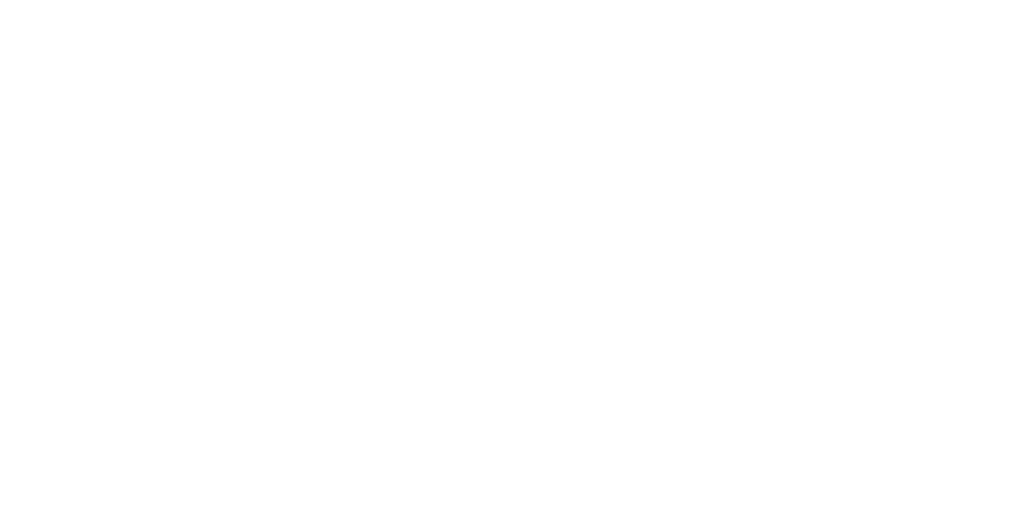

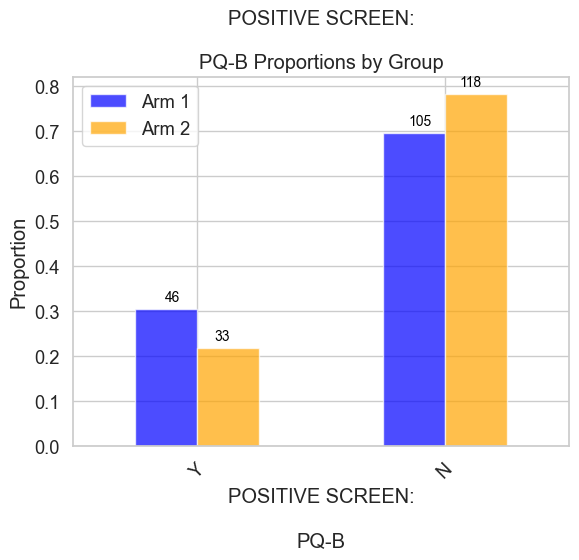

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_mental_column_differences(df1, df2, mental_columns):
    sns.set(font_scale=1.2)
    sns.set_style("whitegrid")

    for column in mental_columns:
        # Create visualizations for each mental health column
        plt.figure(figsize=(10, 5))

        # Combine value counts for both groups ensuring 'Y' is on the left
        combined_table = pd.concat([
            df1[column].value_counts(normalize=True).reindex(['Y', 'N']),
            df2[column].value_counts(normalize=True).reindex(['Y', 'N'])
        ], axis=1, keys=['Arm 1', 'Arm 2']).fillna(0)
        
        # Raw counts for text annotations
        count_table = pd.concat([
            df1[column].value_counts().reindex(['Y', 'N']),
            df2[column].value_counts().reindex(['Y', 'N'])
        ], axis=1, keys=['Arm 1', 'Arm 2']).fillna(0)

        combined_table.plot(kind='bar', color=['blue', 'orange'], alpha=0.7)

        # Add text annotations with raw counts
        for i, (index, row) in enumerate(count_table.iterrows()):
            for j, value in enumerate(row):
                plt.text(i + j * 0.2 - 0.1, combined_table.loc[index].iloc[j] + 0.01, int(value), 
                         ha='center', va='bottom', fontsize=10, color='black')
        
        plt.title(f'{column} Proportions by Group')
        plt.xlabel(column)
        plt.ylabel('Proportion')
        plt.xticks(rotation=45)
        plt.legend()
        plt.show()

# Visualize group differences for columns in mentalLists
visualize_mental_column_differences(arm1Demo, arm2Demo, mentalLists)

## Retention by Arm

In [24]:
arm2Demo['STATUS'].value_counts()

STATUS
LTFU          80
FULL (≥8M)    56
DROP OUT      14
WITHDREW       1
Name: count, dtype: int64

In [25]:
arm1Demo['STATUS'].value_counts()

STATUS
FULL (≥8M)    68
LTFU          59
DROP OUT      21
WITHDREW       3
Name: count, dtype: int64

In [26]:
from scipy.stats import chi2_contingency

def test_retention_rates(df1, df2):
    participation_counts_arm1 = df1['PARTICIPATION'].value_counts()
    participation_counts_arm2 = df2['PARTICIPATION'].value_counts()

    # Create a contingency table
    retention_table = pd.concat([
        participation_counts_arm1,
        participation_counts_arm2
    ], axis=1, keys=['Arm 1', 'Arm 2']).fillna(0)

    print(retention_table)

    # Perform chi-squared test
    chi2, p_value, _, _ = chi2_contingency(retention_table)

    print("Retention Rate Comparison (Full vs Dropped Out):")
    print(f"Chi2 = {chi2:.2f}, P-value = {p_value:.5f}")

# Call the function for statistical testing
# Disabled: references undefined variables and a 'PARTICIPATION' column absent
# from the rosters (they use 'STATUS'); retention is summarized in the next cell.
# test_retention_rates(df_arm1_adherence, df_arm2_adherence)

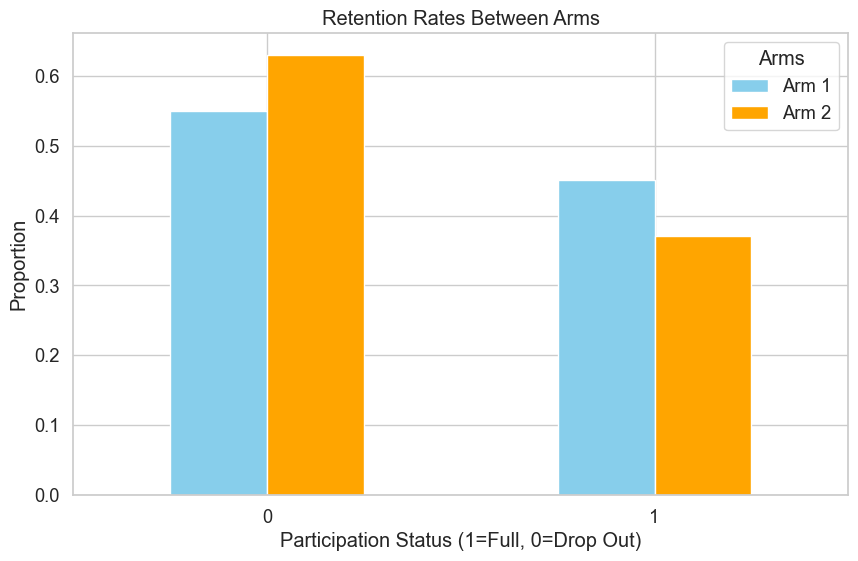

In [27]:
import matplotlib.pyplot as plt

def visualize_retention_rates(retention_table):
    retention_table_normalized = retention_table / retention_table.sum()

    # Plot bar chart
    retention_table_normalized.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'orange'])
    plt.title('Retention Rates Between Arms')
    plt.ylabel('Proportion')
    plt.xlabel('Participation Status (1=Full, 0=Drop Out)')
    plt.xticks(rotation=0)
    plt.legend(title='Arms')
    plt.show()

# Normalize and visualize
retention_table = pd.DataFrame({
    "Arm 1": [83, 68],
    "Arm 2": [95, 56]
}, index=[0, 1])  # 0 = Dropout / 1 = Full
visualize_retention_rates(retention_table)

## Full-Completer Cohort and Per-Participant Adherence (Exploratory)

In [28]:
arm1Demo.STATUS.unique()

<StringArray>
['DROP OUT', 'FULL (≥8M)', 'LTFU', 'WITHDREW']
Length: 4, dtype: str

In [29]:
arm2Demo

     REDCap ID  mm_id  ...    arm       education_collapsed
0          341    362  ...  Arm 2  SOME COLLEGE / ASSOCIATE
1          342    363  ...  Arm 2                BACHELOR'S
2          344    365  ...  Arm 2  SOME COLLEGE / ASSOCIATE
3          348    369  ...  Arm 2  SOME COLLEGE / ASSOCIATE
4          350    371  ...  Arm 2  SOME COLLEGE / ASSOCIATE
..         ...    ...  ...    ...                       ...
146        515    552  ...  Arm 2  SOME COLLEGE / ASSOCIATE
147        520    558  ...  Arm 2   GRADUATE / PROFESSIONAL
148        525    562  ...  Arm 2  SOME COLLEGE / ASSOCIATE
149        530    569  ...  Arm 2  SOME COLLEGE / ASSOCIATE
150        418    444  ...  Arm 2                BACHELOR'S

[151 rows x 86 columns]

In [30]:
arm1Full = arm1Demo[arm1Demo['STATUS'] == 'FULL (≥8M)']

In [31]:
arm1Full.mm_id.unique()

array([ 18,  23,  24,  31,  33,  34,  35,  37,  44,  52,  53,  59,  69,
        73,  85,  88, 108, 117, 125, 127, 128, 142, 143, 154, 159, 160,
       164, 170, 179, 190, 191, 192, 194, 219, 227, 229, 233, 240, 241,
       242, 245, 246, 252, 253, 254, 257, 259, 263, 269, 270, 272, 273,
       275, 276, 280, 281, 282, 283, 284, 285, 293, 294, 296, 304, 305,
       308, 309, 310])

In [32]:
arm1Full['REDCap ID'].unique()

array([  4,  22,  23,  30,  32,  33,  34,  35,  42,  49,  50,  56,  68,
        70,  82,  84, 104, 112, 120, 122, 123, 137, 138, 149, 154, 155,
       159, 165, 171, 183, 184, 185, 187, 210, 217, 219, 223, 229, 230,
       231, 233, 234, 239, 240, 241, 244, 246, 250, 256, 257, 258, 259,
       261, 262, 265, 266, 267, 268, 269, 270, 276, 277, 279, 287, 288,
       290, 291, 292])

In [33]:
df_sleep.UserID.unique()

array([100, 102, 104, 106, 107, 108, 109, 110, 111, 117, 119, 121, 122,
       123, 125, 127, 128, 129, 135, 136, 138, 142, 143, 148, 150, 154,
       158, 159, 160, 164, 168, 170, 171, 173, 174, 175, 178, 179,  18,
       181, 187,  19, 190, 191, 192, 194, 199, 205, 207, 210, 212, 216,
       219,  22, 221, 222, 224, 227, 229,  23, 232, 233, 237, 238,  24,
       240, 241, 242, 245, 246, 252, 253, 254, 257, 259,  26, 263, 269,
       270, 272, 273, 275, 276,  28, 280, 281, 282, 283, 284, 285, 293,
       294, 296,  30, 305, 308, 309,  31, 310,  32,  33,  34,  35, 361,
       362, 364, 365, 366, 367, 368, 369,  37, 371, 372, 373, 374, 375,
       376, 377, 378, 379,  38, 380, 381, 383, 384, 386, 387, 389, 390,
       391, 392, 395, 397, 398, 399, 400, 401, 403, 404, 405, 407, 408,
       409,  41, 411, 412, 413, 416, 421, 422, 424,  43, 430, 434, 435,
       437,  44, 440, 442, 443, 445, 446, 450, 451, 452, 453, 454, 455,
       456, 457, 458, 459, 460, 462, 465, 468, 469, 470, 471, 47

In [34]:
arm1Full

    REDCap ID  mm_id  ...    arm       education_collapsed
21          4     18  ...  Arm 1                BACHELOR'S
22         22     23  ...  Arm 1                BACHELOR'S
23         23     24  ...  Arm 1                BACHELOR'S
24         30     31  ...  Arm 1   GRADUATE / PROFESSIONAL
25         32     33  ...  Arm 1                BACHELOR'S
..        ...    ...  ...    ...                       ...
84        287    304  ...  Arm 1                BACHELOR'S
85        288    305  ...  Arm 1  SOME COLLEGE / ASSOCIATE
86        290    308  ...  Arm 1  SOME COLLEGE / ASSOCIATE
87        291    309  ...  Arm 1  SOME COLLEGE / ASSOCIATE
88        292    310  ...  Arm 1  SOME COLLEGE / ASSOCIATE

[68 rows x 95 columns]

In [35]:
df_symptom_survey[df_symptom_survey['mm_id'] == 18].date.unique()

<DatetimeArray>
['2023-06-27 00:00:00', '2023-07-04 00:00:00', '2023-07-26 00:00:00',
 '2023-08-02 00:00:00', '2023-08-09 00:00:00', '2023-08-16 00:00:00',
 '2023-08-23 00:00:00', '2023-08-30 00:00:00', '2023-09-06 00:00:00',
 '2023-09-14 00:00:00', '2023-09-20 00:00:00', '2023-09-27 00:00:00',
 '2023-10-04 00:00:00', '2023-10-11 00:00:00', '2023-10-18 00:00:00',
 '2023-10-25 00:00:00', '2023-11-01 00:00:00', '2023-11-08 00:00:00',
 '2023-11-15 00:00:00', '2023-11-22 00:00:00', '2023-11-29 00:00:00',
 '2023-12-06 00:00:00', '2023-12-13 00:00:00', '2023-12-20 00:00:00',
 '2023-12-27 00:00:00', '2024-01-03 00:00:00', '2024-01-10 00:00:00',
 '2024-01-17 00:00:00', '2024-01-24 00:00:00', '2024-01-31 00:00:00',
 '2024-02-07 00:00:00', '2024-02-14 00:00:00', '2024-02-22 00:00:00',
 '2024-02-29 00:00:00', '2024-03-06 00:00:00', '2024-03-13 00:00:00']
Length: 36, dtype: datetime64[us]

In [36]:
arm1Full['4YAM Enroll'] = pd.to_datetime(arm1Full['4YAM Enroll'])
arm1Full['4YAM End'] = pd.to_datetime(arm1Full['4YAM End'])
df_sleep['Date'] = pd.to_datetime(df_sleep['Date'])

for user in arm1Full['mm_id'].unique():
    # Get row for this user
    row = arm1Full.loc[arm1Full['mm_id'] == user].iloc[0]
    userStartDate = row['4YAM Enroll']
    userEndDate = row['4YAM End']

    userTotalDays = (userEndDate - userStartDate).days + 1

    userDF = df_anxiety_questionnaire[
        (df_anxiety_questionnaire['mm_id'] == user) &
        (df_anxiety_questionnaire['date'].between(userStartDate, userEndDate))
    ]

    adherence = (userDF['date'].nunique() / (userTotalDays/7)) * 100
    print(f'User {user}: Adherence = {adherence:.2f}% over {userTotalDays} days')

<cell>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
User 18: Adherence = 47.22% over 252 days
User 23: Adherence = 47.98% over 248 days
User 24: Adherence = 42.17% over 249 days
User 31: Adherence = 42.00% over 250 days
User 33: Adherence = 50.40% over 250 days
User 34: Adherence = 39.20% over 250 days
User 35: Adherence = 78.40% over 250 days
User 37: Adherence = 33.60% over 250 days
User 44: Adherence = 51.22% over 246 days
User 52: Adherence = 28.11% over 249 days
User 53: Adherence = 42.17% over 249 days
User 59: Adherence = 80.88% over 251 days
User 69: Adherence = 40.83% over 240 days
User 73: Adherence = 42.34% over 248 days
User 85: Adherence = 50.00% over 252 days
User 88: Adherence = 48.57% over 245 days
User 108: Adherence = 66.67% over 252 days
User 117: Adherence = 56.91% over 246 days
User 125: Adherence = 36.99% over 246 days
User 

In [37]:
arm1Full['Oura Start'] = pd.to_datetime(arm1Full['Oura Start'])
arm1Full['4YAM End'] = pd.to_datetime(arm1Full['4YAM End'])
df_sleep['Date'] = pd.to_datetime(df_sleep['Date'])

for user in arm1Full['mm_id'].unique():
    # Get row for this user
    row = arm1Full.loc[arm1Full['mm_id'] == user].iloc[0]
    userStartDate = row['Oura Start']
    userEndDate = row['4YAM End']

    userTotalDays = (userEndDate - userStartDate).days + 1

    userDF = df_sleep[
        (df_sleep['UserID'] == user) &
        (df_sleep['Date'].between(userStartDate, userEndDate))
    ]

    adherence = (userDF['Date'].nunique() / userTotalDays) * 100
    print(f'User {user}: Adherence = {adherence:.2f}% over {userTotalDays} days')


<cell>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
User 18: Adherence = 98.81% over 252 days
User 23: Adherence = 76.27% over 236 days
User 24: Adherence = 95.38% over 238 days
User 31: Adherence = 72.38% over 239 days
User 33: Adherence = 90.80% over 250 days
User 34: Adherence = 97.91% over 239 days
User 35: Adherence = 92.37% over 236 days
User 37: Adherence = 44.78% over 230 days
User 44: Adherence = 71.67% over 233 days
User 52: Adherence = 95.67% over 231 days
User 53: Adherence = 66.53% over 239 days
User 59: Adherence = 96.17% over 235 days
User 69: Adherence = 97.71% over 218 days
User 73: Adherence = 86.19% over 239 days
User 85: Adherence = 98.79% over 247 days
User 88: Adherence = 96.46% over 226 days
User 108: Adherence = 62.88% over 229 days
User 117: Adherence = 98.22% over 225 days
User 125: Adherence = 99.50% over 201 days
User 

# Adherence by Data Source

Per-participant adherence for each study activity (Oura ring, scheduled questionnaires, and daily surveys), followed by between-arm comparisons, visualizations, validation checks, and temporal-trend models.

In [38]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu
from scipy.stats import ttest_ind

# Define arm1Full and arm2Full
arm1Full = arm1Demo[arm1Demo['STATUS'] == 'FULL (≥8M)'].copy()
arm2Full = arm2Demo[arm2Demo['STATUS'] == 'FULL (≥8M)'].copy()

print(f"Arm 1 Full participants: {len(arm1Full)}")
print(f"Arm 2 Full participants: {len(arm2Full)}")
print(f"Total Full participants: {len(arm1Full) + len(arm2Full)}")

Arm 1 Full participants: 68
Arm 2 Full participants: 56
Total Full participants: 124


## Adherence Calculation Functions

Per-data-source adherence functions: continuous Oura, combined Oura (sleep OR activity), fixed-schedule questionnaires, adaptive-schedule questionnaires, and daily questionnaires.

In [39]:
# Create the adherence calculation function

def calculate_adherence_for_datasource(enrollment_df, data_df, 
                                       data_source_name,
                                       use_oura_start=False,
                                       user_id_col='UserID',
                                       date_col='Date'):
    """
    Calculate adherence rate for each participant for a given data source
    
    Parameters:
    -----------
    enrollment_df : DataFrame
        Dataframe with enrollment information (arm1Full or arm2Full)
    data_df : DataFrame  
        Dataframe with the data source (e.g., df_sleep, df_activity)
    data_source_name : str
        Name of the data source for the column
    use_oura_start : bool
        If True, use 'Oura Start' instead of '4YAM Enroll' as start date
    user_id_col : str
        Column name for user ID in data_df (default 'UserID', can be 'mm_id')
    date_col : str
        Column name for date in data_df (default 'date')
    
    Returns:
    --------
    pandas Series with mm_id as index and adherence percentage as values
    """
    
    adherence_dict = {}
    
    # Ensure date columns are datetime
    start_col = 'Oura Start' if use_oura_start else '4YAM Enroll'
    
    for idx, row in enrollment_df.iterrows():
        mm_id = row['mm_id']
        
        # Get start and end dates
        start_date = pd.to_datetime(row[start_col])
        end_date = pd.to_datetime(row['4YAM End'])
        
        # Skip if dates are missing
        if pd.isna(start_date) or pd.isna(end_date):
            adherence_dict[mm_id] = np.nan
            continue
        
        # Calculate expected days
        expected_days = (end_date - start_date).days + 1
        
        # Get user's data within date range
        user_data = data_df[
            (data_df[user_id_col] == mm_id) &
            (pd.to_datetime(data_df[date_col]).between(start_date, end_date))
        ]
        
        # Calculate unique days with data
        actual_days = pd.to_datetime(user_data[date_col]).nunique()
        
        # Calculate adherence percentage
        adherence_pct = (actual_days / expected_days * 100) if expected_days > 0 else 0
        adherence_dict[mm_id] = adherence_pct
    
    return pd.Series(adherence_dict, name=data_source_name)

print("Adherence calculation function defined.")

Adherence calculation function defined.


In [40]:
# Create function for combined Oura data (Sleep OR Activity)

def calculate_oura_combined_adherence(enrollment_df, sleep_df, activity_df):
    """
    Calculate adherence for days with EITHER sleep (nighttime) OR activity (daytime) data
    
    This represents any day the participant wore the Oura ring (nighttime, daytime, or both)
    
    Parameters:
    -----------
    enrollment_df : DataFrame
        Dataframe with enrollment information
    sleep_df : DataFrame
        Oura sleep dataframe
    activity_df : DataFrame
        Oura activity dataframe
    
    Returns:
    --------
    pandas Series with mm_id as index and adherence percentage as values
    """
    
    adherence_dict = {}
    
    for idx, row in enrollment_df.iterrows():
        mm_id = row['mm_id']
        
        # Get start and end dates (use Oura Start)
        start_date = pd.to_datetime(row['Oura Start'])
        end_date = pd.to_datetime(row['4YAM End'])
        
        # Skip if dates are missing
        if pd.isna(start_date) or pd.isna(end_date):
            adherence_dict[mm_id] = np.nan
            continue
        
        # Calculate expected days
        expected_days = (end_date - start_date).days + 1
        
        # Get user's sleep data within date range
        user_sleep = sleep_df[
            (sleep_df['UserID'] == mm_id) &
            (pd.to_datetime(sleep_df['Date']).between(start_date, end_date))
        ]
        
        # Get user's activity data within date range
        user_activity = activity_df[
            (activity_df['UserID'] == mm_id) &
            (pd.to_datetime(activity_df['Date']).between(start_date, end_date))
        ]
        
        # Get unique days with sleep data
        sleep_days = set(pd.to_datetime(user_sleep['Date']).dt.date)
        
        # Get unique days with activity data
        activity_days = set(pd.to_datetime(user_activity['Date']).dt.date)
        
        # Find days with EITHER sleep OR activity (or both)
        any_data_days = sleep_days.union(activity_days)
        
        # Calculate adherence percentage
        actual_days = len(any_data_days)
        adherence_pct = (actual_days / expected_days * 100) if expected_days > 0 else 0
        adherence_dict[mm_id] = adherence_pct
    
    return pd.Series(adherence_dict, name='Oura Any Day (Sleep OR Activity)')

print("Combined Oura adherence calculation function defined.")

Combined Oura adherence calculation function defined.


In [41]:
scheduled_days = df_questionnaire_schedules_2025_05_11[df_questionnaire_schedules_2025_05_11['questionnaire'] == 'FUXP01-PHQ-9']['study_day'].unique()

In [42]:
user_responses = df_depression_questionnaire[df_depression_questionnaire['mm_id'] == 18]
if 'daysSince' in user_responses.columns:
    completed_days = set(user_responses['daysSince'].dropna().astype(int))

In [43]:
start_date = pd.to_datetime(arm1Full[arm1Full['mm_id'] == 18]['4YAM Enroll'].values[0])
end_date = pd.to_datetime(arm1Full[arm1Full['mm_id'] == 18]['4YAM End'].values[0])
study_length_days = (end_date - start_date).days + 1
applicable_scheduled_days = [day for day in scheduled_days if day <= study_length_days]

In [44]:
[x for x in completed_days if x > 0]

[225, 197, 72, 169, 232, 43, 141, 16, 114, 246, 57, 218, 92, 29]

In [45]:
applicable_scheduled_days

[np.int64(1), np.int64(15), np.int64(29), np.int64(43), np.int64(57), np.int64(71), np.int64(85), np.int64(92), np.int64(99), np.int64(106), np.int64(113), np.int64(120), np.int64(127), np.int64(134), np.int64(141), np.int64(148), np.int64(155), np.int64(162), np.int64(169), np.int64(176), np.int64(183), np.int64(190), np.int64(197), np.int64(204), np.int64(211), np.int64(218), np.int64(225), np.int64(232), np.int64(239), np.int64(246)]

In [46]:
# Function for scheduled questionnaire adherence (NON-adaptive)
# For fixed-schedule questionnaires like EBT, PVT
# Uses daysSince, count-based, capped at 4YAM End

def calculate_scheduled_questionnaire_adherence(enrollment_df, questionnaire_df, 
                                                schedule_df, questionnaire_id):
    adherence_dict = {}
    
    scheduled_days = sorted(schedule_df[
        schedule_df['questionnaire'] == questionnaire_id
    ]['study_day'].unique())
    
    if len(scheduled_days) == 0:
        print(f'  Warning: No scheduled days found for {questionnaire_id}')
        return pd.Series(adherence_dict, name=questionnaire_id)
    
    for idx, row in enrollment_df.iterrows():
        mm_id = row['mm_id']
        start_date = pd.to_datetime(row['4YAM Enroll'])
        end_date = pd.to_datetime(row['4YAM End'])
        
        if pd.isna(start_date) or pd.isna(end_date):
            adherence_dict[mm_id] = np.nan
            continue
        
        max_ds = (end_date - start_date).days
        
        user_responses = questionnaire_df[
            (questionnaire_df['mm_id'] == mm_id) &
            (questionnaire_df['complete'] != False) &
            (questionnaire_df['daysSince'] >= 0) &
            (questionnaire_df['daysSince'] <= max_ds)
        ]
        completions = user_responses['daysSince'].dropna().astype(int).nunique()
        
        # Convert schedule to daysSince (0-indexed)
        applicable = [d - 1 for d in scheduled_days if (d - 1) <= max_ds]
        
        if len(applicable) == 0:
            adherence_dict[mm_id] = np.nan
            continue
        
        adherence_dict[mm_id] = (completions / len(applicable) * 100)
    
    return pd.Series(adherence_dict, name=questionnaire_id)

print('Non-adaptive scheduled questionnaire adherence function defined.')

Non-adaptive scheduled questionnaire adherence function defined.


In [47]:
# Function for ADAPTIVE questionnaire adherence
# For PHQ-9, OASIS, ASRM — uses adaptive schedule configuration
# Uses daysSince, count-based, capped at 4YAM End, cadence-aware denominators

def calculate_adaptive_questionnaire_adherence(enrollment_df, questionnaire_df,
                                               schedule_df, questionnaire_id,
                                               adaptive_config_df, config_col):
    """
    Calculate adherence for adaptive questionnaires.
    Baseline period uses fixed schedule. Adaptive period uses per-user cadence config.
    
    Parameters:
    -----------
    config_col : str
        Column in adaptive_config_df for this questionnaire (e.g., 'PHQ-9', 'OASIS', 'ASRM')
    """
    adherence_dict = {}
    
    # Get all scheduled days for this questionnaire
    all_sched_days = sorted(schedule_df[
        schedule_df['questionnaire'] == questionnaire_id
    ]['study_day'].unique())
    
    if len(all_sched_days) == 0:
        print(f'  Warning: No scheduled days found for {questionnaire_id}')
        return pd.Series(adherence_dict, name=questionnaire_id)
    
    # Split into baseline and adaptive (daysSince space)
    adaptive_cutoff_ds = 84  # study_day 85 -> daysSince 84
    baseline_ds = [d - 1 for d in all_sched_days if (d - 1) < adaptive_cutoff_ds]
    adaptive_all_ds = [d - 1 for d in all_sched_days if (d - 1) >= adaptive_cutoff_ds]
    
    # Monthly subset: every 28 days anchored to first scheduled day
    first_day = all_sched_days[0] if all_sched_days else 0
    monthly_ds = [d - 1 for d in all_sched_days if (d - 1) >= adaptive_cutoff_ds and (d - first_day) % 28 == 0]
    
    for idx, row in enrollment_df.iterrows():
        mm_id = row['mm_id']
        start_date = pd.to_datetime(row['4YAM Enroll'])
        end_date = pd.to_datetime(row['4YAM End'])
        
        if pd.isna(start_date) or pd.isna(end_date):
            adherence_dict[mm_id] = np.nan
            continue
        
        max_ds = (end_date - start_date).days
        
        # All completions within enrollment period
        user_resp = questionnaire_df[
            (questionnaire_df['mm_id'] == mm_id) &
            (questionnaire_df['complete'] != False) &
            (questionnaire_df['daysSince'] >= 0) &
            (questionnaire_df['daysSince'] <= max_ds)
        ]
        completions = user_resp['daysSince'].dropna().astype(int).nunique()
        
        # Expected baseline
        baseline_exp = len([d for d in baseline_ds if d <= max_ds])
        
        # Adaptive config for this user
        user_cfg = adaptive_config_df[
            adaptive_config_df['mm_id'] == mm_id
        ][['study_day', config_col]].sort_values('study_day').to_dict('records')
        
        adaptive_exp = 0
        for d in adaptive_all_ds:
            if d > max_ds:
                break
            active = None
            for cfg in reversed(user_cfg):
                if cfg['study_day'] <= d + 1:  # convert daysSince back to study_day
                    active = cfg[config_col]
                    break
            if active is None:
                continue
            if active == 'weekly':
                adaptive_exp += 1
            elif active == 'monthly' and d in monthly_ds:
                adaptive_exp += 1
        
        total_exp = baseline_exp + adaptive_exp
        
        if total_exp == 0:
            adherence_dict[mm_id] = np.nan
            continue
        
        adherence_dict[mm_id] = (completions / total_exp * 100)
    
    return pd.Series(adherence_dict, name=questionnaire_id)

print('Adaptive questionnaire adherence function defined.')

Adaptive questionnaire adherence function defined.


In [48]:
# Function for daily questionnaires with completion filter

def calculate_daily_questionnaire_adherence(enrollment_df, questionnaire_df, 
                                           data_source_name,
                                           user_id_col='mm_id',
                                           date_col='date',
                                           complete_col='complete'):
    """
    Calculate adherence for daily questionnaires, only counting completed responses
    
    Parameters:
    -----------
    enrollment_df : DataFrame
        Dataframe with enrollment information
    questionnaire_df : DataFrame
        Dataframe with questionnaire responses
    data_source_name : str
        Name for the data source
    user_id_col : str
        Column name for user ID (default 'mm_id')
    date_col : str
        Column name for date (default 'date')
    complete_col : str
        Column name for completion status (default 'complete')
    
    Returns:
    --------
    pandas Series with mm_id as index and adherence percentage as values
    """
    
    adherence_dict = {}
    
    for idx, row in enrollment_df.iterrows():
        mm_id = row['mm_id']
        
        # Get start and end dates
        start_date = pd.to_datetime(row['4YAM Enroll'])
        end_date = pd.to_datetime(row['4YAM End'])
        
        # Skip if dates are missing
        if pd.isna(start_date) or pd.isna(end_date):
            adherence_dict[mm_id] = np.nan
            continue
        
        # Calculate expected days
        expected_days = (end_date - start_date).days + 1
        
        # Get user's data within date range
        user_data = questionnaire_df[
            (questionnaire_df[user_id_col] == mm_id) &
            (pd.to_datetime(questionnaire_df[date_col]).between(start_date, end_date))
        ]
        
        # Filter for completed responses only
        if complete_col in user_data.columns:
            user_data = user_data[user_data[complete_col] == True]
        
        # Calculate unique days with completed data
        actual_days = pd.to_datetime(user_data[date_col]).nunique()
        
        # Calculate adherence percentage
        adherence_pct = (actual_days / expected_days * 100) if expected_days > 0 else 0
        adherence_dict[mm_id] = adherence_pct
    
    return pd.Series(adherence_dict, name=data_source_name)

print("Daily questionnaire adherence function defined.")

Daily questionnaire adherence function defined.


## Data Sources and Cadences

Data sources and their collection cadences.

### Continuous / daily sources
1. **Sleep (Oura)** - nighttime data, expected daily
2. **Activity (Oura)** - daytime data, expected daily
3. **Oura Any Day** - combined metric: days with EITHER sleep OR activity
4. **Symptom Survey** - daily questionnaire, completed responses only

### Scheduled questionnaires
- **PHQ-9 (Depression)** - `FUXP01-PHQ-9` (bi-weekly baseline, then adaptive)
- **OASIS (Anxiety)** - `FUXP01-OASIS` (weekly baseline, then adaptive)
- **ASRM (Mania)** - `FUXP01-ASRM` (weekly baseline, then adaptive)
- **FAS (Fatigue)** - `FUXP01-FAS` (adaptive)
- **EBT (Emotional Bias Test)** - `FUXP01-EBT` (fixed schedule)
- **PVT (Psychomotor Vigilance Test)** - `FUXP01-PVT` (fixed schedule)

### Adherence definitions
**Daily / continuous:** unique days with data / expected days x 100%.

**Scheduled:** completed assessments / scheduled assessments x 100%, using `df_questionnaire_schedules_2025_05_11` for scheduled days, counting only scheduled days within each participant's study period.

## Worked Example: Oura "Any Day" Adherence

In [49]:
# Worked example: combined Oura (sleep OR activity) adherence

print("="*80)
print("EXAMPLE: How Oura Any Day Adherence is Calculated")
print("="*80)

# Pick a sample participant
example_mm_id = arm1Full.iloc[0]['mm_id']
example_row = arm1Full[arm1Full['mm_id'] == example_mm_id].iloc[0]

oura_start = pd.to_datetime(example_row['Oura Start'])
end_date = pd.to_datetime(example_row['4YAM End'])

if pd.notna(oura_start):
    expected_days = (end_date - oura_start).days + 1
    
    # Get sleep data
    user_sleep = df_sleep[
        (df_sleep['UserID'] == example_mm_id) &
        (pd.to_datetime(df_sleep['Date']).between(oura_start, end_date))
    ]
    
    # Get activity data
    user_activity = df_activity[
        (df_activity['UserID'] == example_mm_id) &
        (pd.to_datetime(df_activity['Date']).between(oura_start, end_date))
    ]
    
    # Get unique days
    sleep_days = set(pd.to_datetime(user_sleep['Date']).dt.date)
    activity_days = set(pd.to_datetime(user_activity['Date']).dt.date)
    any_data_days = sleep_days.union(activity_days)  # EITHER sleep OR activity
    
    # Days with only sleep or only activity
    sleep_only = sleep_days - activity_days
    activity_only = activity_days - sleep_days
    both = sleep_days.intersection(activity_days)
    
    print(f"\nParticipant mm_id {example_mm_id}:")
    print(f"  Period: {oura_start.date()} to {end_date.date()}")
    print(f"  Expected days: {expected_days}")
    print(f"\nData breakdown:")
    print(f"  Days with sleep data only:     {len(sleep_only):3d} days")
    print(f"  Days with activity data only:  {len(activity_only):3d} days")
    print(f"  Days with BOTH:                {len(both):3d} days")
    print(f"  ------------------------------------")
    print(f"  Days with ANY data (OR):       {len(any_data_days):3d} days  Uses this for combined metric")
    
    print(f"\nAdherence rates:")
    print(f"  Sleep only:        {len(sleep_days)/expected_days*100:5.1f}%")
    print(f"  Activity only:     {len(activity_days)/expected_days*100:5.1f}%")
    print(f"  Any Day (OR):      {len(any_data_days)/expected_days*100:5.1f}%  Combined metric")
    
    print("\n" + "="*80)
    print("Any Day adherence counts days with EITHER sleep OR activity (or both)")
    print("This represents any Oura ring usage (nighttime, daytime, or full day)")
    print("="*80)
else:
    print(f"\nParticipant mm_id {example_mm_id} has no Oura Start date")

EXAMPLE: How Oura Any Day Adherence is Calculated

Participant mm_id 18:
  Period: 2023-07-08 to 2024-03-15
  Expected days: 252

Data breakdown:
  Days with sleep data only:       0 days
  Days with activity data only:    3 days
  Days with BOTH:                249 days
  ------------------------------------
  Days with ANY data (OR):       252 days  Uses this for combined metric

Adherence rates:
  Sleep only:         98.8%
  Activity only:     100.0%
  Any Day (OR):      100.0%  Combined metric

Any Day adherence counts days with EITHER sleep OR activity (or both)
This represents any Oura ring usage (nighttime, daytime, or full day)


## Compute Adherence Across All Data Sources

In [50]:
# Calculate adherence for each data source
# Uses ADAPTIVE logic for PHQ-9, OASIS, ASRM
# Uses combined Oura (Sleep OR Activity) instead of separate
# Uses daysSince, count-based, capped at 4YAM End

all_full = pd.concat([arm1Full, arm2Full], ignore_index=False)

adherence_results = {}

print('='*80)
print('CALCULATING ADHERENCE FOR ALL DATA SOURCES')
print('(daysSince, count-based, capped at 4YAM End, adaptive where applicable)')
print('='*80)

# 1. Oura Combined (Sleep OR Activity)
print(f'\n1. Oura (Sleep OR Activity)...')
adherence_results['Oura (Sleep OR Activity)'] = calculate_oura_combined_adherence(
    enrollment_df=all_full,
    sleep_df=df_sleep,
    activity_df=df_activity
)
print(f'   Mean: {adherence_results["Oura (Sleep OR Activity)"].mean():.2f}%')

# 2. FAS - Fatigue Assessment Scale (ADAPTIVE)
print(f'\n2. FAS Fatigue (ADAPTIVE)...')
adherence_results['FAS (Fatigue)'] = calculate_adaptive_questionnaire_adherence(
    enrollment_df=all_full,
    questionnaire_df=df_fatigue_questionnaire,
    schedule_df=df_questionnaire_schedules_2025_05_11,
    questionnaire_id='FUXP01-FAS',
    adaptive_config_df=df_adaptive_schedule_configuration,
    config_col='FAS'
)
print(f'   Mean: {adherence_results["FAS (Fatigue)"].mean():.2f}%')

# 3. Weekly Symptom Survey
print(f'\n3. Weekly Symptom Survey...')
adherence_results['Weekly Symptom Survey'] = calculate_scheduled_questionnaire_adherence(
    enrollment_df=all_full,
    questionnaire_df=df_symptom_survey,
    schedule_df=df_questionnaire_schedules_2025_05_11,
    questionnaire_id='FUXP01-SYMPTOM'
)
print(f'   Mean: {adherence_results["Weekly Symptom Survey"].mean():.2f}%')

# 4. PHQ-9 (ADAPTIVE)
print(f'\n4. PHQ-9 Depression (ADAPTIVE)...')
adherence_results['PHQ-9 (Depression)'] = calculate_adaptive_questionnaire_adherence(
    enrollment_df=all_full,
    questionnaire_df=df_depression_questionnaire,
    schedule_df=df_questionnaire_schedules_2025_05_11,
    questionnaire_id='FUXP01-PHQ-9',
    adaptive_config_df=df_adaptive_schedule_configuration,
    config_col='PHQ-9'
)
print(f'   Mean: {adherence_results["PHQ-9 (Depression)"].mean():.2f}%')

# 5. OASIS (ADAPTIVE)
print(f'\n5. OASIS Anxiety (ADAPTIVE)...')
adherence_results['OASIS (Anxiety)'] = calculate_adaptive_questionnaire_adherence(
    enrollment_df=all_full,
    questionnaire_df=df_anxiety_questionnaire,
    schedule_df=df_questionnaire_schedules_2025_05_11,
    questionnaire_id='FUXP01-OASIS',
    adaptive_config_df=df_adaptive_schedule_configuration,
    config_col='OASIS'
)
print(f'   Mean: {adherence_results["OASIS (Anxiety)"].mean():.2f}%')

# 6. ASRM (ADAPTIVE)
print(f'\n6. ASRM Mania (ADAPTIVE)...')
adherence_results['ASRM (Mania)'] = calculate_adaptive_questionnaire_adherence(
    enrollment_df=all_full,
    questionnaire_df=df_mania_questionnaire,
    schedule_df=df_questionnaire_schedules_2025_05_11,
    questionnaire_id='FUXP01-ASRM',
    adaptive_config_df=df_adaptive_schedule_configuration,
    config_col='ASRM'
)
print(f'   Mean: {adherence_results["ASRM (Mania)"].mean():.2f}%')

# 7. EBT (fixed schedule)
print(f'\n7. EBT Emotional Bias...')
adherence_results['EBT (Emotional Bias)'] = calculate_scheduled_questionnaire_adherence(
    enrollment_df=all_full,
    questionnaire_df=df_emotional_bias_test,
    schedule_df=df_questionnaire_schedules_2025_05_11,
    questionnaire_id='FUXP01-EBT'
)
print(f'   Mean: {adherence_results["EBT (Emotional Bias)"].mean():.2f}%')

# 8. PVT (fixed schedule)
print(f'\n8. PVT Psychomotor Vigilance...')
adherence_results['PVT (Psychomotor Vigilance)'] = calculate_scheduled_questionnaire_adherence(
    enrollment_df=all_full,
    questionnaire_df=df_psychomotor_vigilance_test,
    schedule_df=df_questionnaire_schedules_2025_05_11,
    questionnaire_id='FUXP01-PVT'
)
print(f'   Mean: {adherence_results["PVT (Psychomotor Vigilance)"].mean():.2f}%')

# 9. Daily Stress Survey (FUXP01-STRESS - scheduled every study day)
# Date-based daily adherence: unique completed days / enrollment span
print(f'\n9. Daily Stress Survey...')
adherence_results['Daily Stress Survey'] = calculate_daily_questionnaire_adherence(
    enrollment_df=all_full,
    questionnaire_df=df_stress_questionnaire,
    data_source_name='Daily Stress Survey'
)
print(f'   Mean: {adherence_results["Daily Stress Survey"].mean():.2f}%')

print('\n' + '='*80)
print('ADHERENCE CALCULATION COMPLETED')
print('='*80)

CALCULATING ADHERENCE FOR ALL DATA SOURCES
(daysSince, count-based, capped at 4YAM End, adaptive where applicable)

1. Oura (Sleep OR Activity)...
   Mean: 82.67%

2. FAS Fatigue (ADAPTIVE)...
   Mean: 62.41%

3. Weekly Symptom Survey...
   Mean: 63.87%

4. PHQ-9 Depression (ADAPTIVE)...
   Mean: 57.34%

5. OASIS Anxiety (ADAPTIVE)...
   Mean: 63.81%

6. ASRM Mania (ADAPTIVE)...
   Mean: 62.86%

7. EBT Emotional Bias...
   Mean: 49.20%

8. PVT Psychomotor Vigilance...
   Mean: 46.82%

9. Daily Stress Survey...
   Mean: 39.09%

ADHERENCE CALCULATION COMPLETED


In [51]:
# Create master adherence dataframe

# Create dataframe with participants as rows and data sources as columns
adherence_df = pd.DataFrame(adherence_results)

# Add arm information
adherence_df['arm'] = adherence_df.index.map(
    lambda mm_id: 'Arm 1' if mm_id in arm1Full['mm_id'].values else 'Arm 2'
)

# Reorder columns to have arm first
cols = ['arm'] + [col for col in adherence_df.columns if col != 'arm']
adherence_df = adherence_df[cols]

print("Master Adherence Dataframe:")
print("="*80)
print(f"Shape: {adherence_df.shape}")
print(f"\nFirst 10 rows:")
print(adherence_df.head(10))

print(f"\nSummary Statistics:")
print(adherence_df.describe().round(2))

Master Adherence Dataframe:
Shape: (124, 10)

First 10 rows:
      arm  ...  Daily Stress Survey
18  Arm 1  ...            88.888889
23  Arm 1  ...            37.096774
24  Arm 1  ...            44.578313
31  Arm 1  ...            60.000000
33  Arm 1  ...            35.200000
34  Arm 1  ...            41.600000
35  Arm 1  ...            62.800000
37  Arm 1  ...            41.200000
44  Arm 1  ...            45.121951
52  Arm 1  ...            37.349398

[10 rows x 10 columns]

Summary Statistics:
       Oura (Sleep OR Activity)  ...  Daily Stress Survey
count                    121.00  ...               124.00
mean                      82.67  ...                39.09
std                       23.60  ...                19.34
min                        0.00  ...                 4.44
25%                       74.68  ...                23.62
50%                       93.45  ...                38.62
75%                       99.58  ...                51.16
max                      100.00  .

In [52]:
adherence_df

       arm  ...  Daily Stress Survey
18   Arm 1  ...            88.888889
23   Arm 1  ...            37.096774
24   Arm 1  ...            44.578313
31   Arm 1  ...            60.000000
33   Arm 1  ...            35.200000
..     ...  ...                  ...
560  Arm 2  ...            46.530612
561  Arm 2  ...            21.224490
459  Arm 2  ...            67.886179
564  Arm 2  ...            15.510204
565  Arm 2  ...            38.775510

[124 rows x 10 columns]

## Between-Arm Adherence Comparison

In [53]:
# Compare adherence between arms using statistical tests

def compare_adherence_between_arms(adherence_df, data_source_col, categorize_threshold=80):
    """
    Compare adherence between Arm 1 and Arm 2 for a specific data source
    
    Uses two tests:
    1. Chi-squared test on categorized adherence (High ≥ threshold vs Low < threshold)
    2. Mann-Whitney U test on continuous adherence percentages
    
    Parameters:
    -----------
    adherence_df : DataFrame
        Master adherence dataframe with 'arm' column
    data_source_col : str
        Column name of the data source to compare
    categorize_threshold : int
        Threshold for categorizing adherence as High (default 80%)
    """
    
    print("="*80)
    print(f"ADHERENCE COMPARISON: {data_source_col}")
    print("="*80)
    
    # Split by arm
    arm1_data = adherence_df[adherence_df['arm'] == 'Arm 1'][data_source_col].dropna()
    arm2_data = adherence_df[adherence_df['arm'] == 'Arm 2'][data_source_col].dropna()
    
    # Check if we have data
    if len(arm1_data) == 0 or len(arm2_data) == 0:
        print("\nWARNING: Insufficient data for comparison (one or both arms have no data)")
        return {
            'data_source': data_source_col,
            'arm1_n': len(arm1_data),
            'arm1_mean': np.nan,
            'arm1_sd': np.nan,
            'arm2_n': len(arm2_data),
            'arm2_mean': np.nan,
            'arm2_sd': np.nan,
            'chi2': np.nan,
            'chi2_p': np.nan,
            'mann_whitney_u': np.nan,
            'mann_whitney_p': np.nan
        }
    
    print(f"\nArm 1: n={len(arm1_data)}, Mean={arm1_data.mean():.2f}%, SD={arm1_data.std():.2f}%")
    print(f"Arm 2: n={len(arm2_data)}, Mean={arm2_data.mean():.2f}%, SD={arm2_data.std():.2f}%")
    
    # Chi-squared test on categorized adherence
    print(f"\n{'-'*80}")
    print(f"Chi-squared test (categorized adherence)")
    print(f"{'-'*80}")
    print(f"Threshold: {categorize_threshold}% (High ≥ {categorize_threshold}%, Low < {categorize_threshold}%)")
    
    # Categorize adherence
    arm1_high = (arm1_data >= categorize_threshold).sum()
    arm1_low = (arm1_data < categorize_threshold).sum()
    arm2_high = (arm2_data >= categorize_threshold).sum()
    arm2_low = (arm2_data < categorize_threshold).sum()
    
    # Create contingency table
    contingency = np.array([[arm1_high, arm1_low], [arm2_high, arm2_low]])
    
    print(f"\nContingency Table:")
    cont_df = pd.DataFrame(contingency, 
                           index=['Arm 1', 'Arm 2'], 
                           columns=[f'High (≥{categorize_threshold}%)', f'Low (<{categorize_threshold}%)'])
    print(cont_df)
    
    print(f"\nPercentages:")
    print(f"Arm 1: {arm1_high}/{len(arm1_data)} ({arm1_high/len(arm1_data)*100:.1f}%) high adherence")
    print(f"Arm 2: {arm2_high}/{len(arm2_data)} ({arm2_high/len(arm2_data)*100:.1f}%) high adherence")
    
    # Check if contingency table is valid for chi-squared
    chi2 = np.nan
    p_chi = np.nan
    
    # Check for zero columns (all in one category)
    if contingency.sum(axis=0).min() == 0:
        print(f"\nChi-squared test cannot be performed:")
        print(f"  All participants are in the same category (all high or all low adherence)")
        print(f"  No variation to test - both arms have identical categorization")
        chi2_valid = False
    # Check for zero rows (one arm has no participants)
    elif contingency.sum(axis=1).min() == 0:
        print(f"\nChi-squared test cannot be performed:")
        print(f"  One arm has no participants in this data source")
        chi2_valid = False
    else:
        chi2_valid = True
        
        # Perform chi-squared test
        try:
            chi2, p_chi, dof, expected = chi2_contingency(contingency)
            
            print(f"\nExpected Frequencies:")
            exp_df = pd.DataFrame(expected, 
                                  index=['Arm 1', 'Arm 2'], 
                                  columns=[f'High (≥{categorize_threshold}%)', f'Low (<{categorize_threshold}%)'])
            print(exp_df.round(2))
            
            min_expected = expected.min()
            print(f"\nMinimum expected frequency: {min_expected:.2f}")
            
            if min_expected >= 5:
                print(f"Chi-squared assumptions met (all expected frequencies ≥ 5)")
                print(f"\nChi-squared test results:")
                print(f"  χ² = {chi2:.4f}")
                print(f"  df = {dof}")
                print(f"  p-value = {p_chi:.4f}")
                
                if p_chi < 0.05:
                    print(f"\n** Significant difference in adherence between arms (p < 0.05)")
                else:
                    print(f"\n** No significant difference in adherence between arms (p ≥ 0.05)")
            else:
                print(f"Chi-squared assumption violated (expected frequency < 5)")
                print(f"  Consider using Fisher's exact test or increasing sample size")
                print(f"\nChi-squared results (interpret with caution):")
                print(f"  χ² = {chi2:.4f}, p-value = {p_chi:.4f}")
        except ValueError as e:
            print(f"\nChi-squared test failed: {e}")
            chi2_valid = False
    
    # Mann-Whitney U test on continuous data
    print(f"\n{'-'*80}")
    print(f"Mann-Whitney U test (continuous adherence %)")
    print(f"{'-'*80}")
    
    try:
        u_stat, p_mann = mannwhitneyu(arm1_data, arm2_data, alternative='two-sided')
        
        print(f"\nMann-Whitney U test results:")
        print(f"  U-statistic = {u_stat:.2f}")
        print(f"  p-value = {p_mann:.4f}")
        
        if p_mann < 0.05:
            print(f"\n** Significant difference in adherence between arms (p < 0.05)")
        else:
            print(f"\n** No significant difference in adherence between arms (p ≥ 0.05)")
    except Exception as e:
        print(f"\nMann-Whitney U test failed: {e}")
        u_stat = np.nan
        p_mann = np.nan
    
    print("\n" + "="*80)
    
    return {
        'data_source': data_source_col,
        'arm1_n': len(arm1_data),
        'arm1_mean': arm1_data.mean(),
        'arm1_sd': arm1_data.std(),
        'arm2_n': len(arm2_data),
        'arm2_mean': arm2_data.mean(),
        'arm2_sd': arm2_data.std(),
        'chi2': chi2,
        'chi2_p': p_chi,
        'mann_whitney_u': u_stat,
        'mann_whitney_p': p_mann
    }

print("Comparison function defined.")

Comparison function defined.


In [54]:
# Run comparisons for all data sources

comparison_results = []

for data_source in [col for col in adherence_df.columns if col != 'arm']:
    result = compare_adherence_between_arms(adherence_df, data_source, categorize_threshold=80)
    comparison_results.append(result)
    print("\n")  # Add spacing between results

# Create summary table
summary_df = pd.DataFrame(comparison_results)
print("\n" + "="*80)
print("SUMMARY TABLE: Adherence Comparison Results")
print("="*80)
print(summary_df.to_string(index=False))

# Export adherence dataframe
print("\n" + "="*80)
print("MASTER ADHERENCE DATAFRAME")
print("="*80)
print(adherence_df)

ADHERENCE COMPARISON: Oura (Sleep OR Activity)

Arm 1: n=68, Mean=89.56%, SD=17.00%
Arm 2: n=53, Mean=73.83%, SD=27.76%

--------------------------------------------------------------------------------
Chi-squared test (categorized adherence)
--------------------------------------------------------------------------------
Threshold: 80% (High ≥ 80%, Low < 80%)

Contingency Table:
       High (≥80%)  Low (<80%)
Arm 1           55          13
Arm 2           25          28

Percentages:
Arm 1: 55/68 (80.9%) high adherence
Arm 2: 25/53 (47.2%) high adherence

Expected Frequencies:
       High (≥80%)  Low (<80%)
Arm 1        44.96       23.04
Arm 2        35.04       17.96

Minimum expected frequency: 17.96
Chi-squared assumptions met (all expected frequencies ≥ 5)

Chi-squared test results:
  χ² = 13.6431
  df = 1
  p-value = 0.0002

** Significant difference in adherence between arms (p < 0.05)

--------------------------------------------------------------------------------
Mann-Whitney

In [55]:
# Create simplified summary table

# Create summary table with requested columns
summary_table_data = []

for data_source in [col for col in adherence_df.columns if col != 'arm']:
    arm1_data = adherence_df[adherence_df['arm'] == 'Arm 1'][data_source].dropna()
    arm2_data = adherence_df[adherence_df['arm'] == 'Arm 2'][data_source].dropna()
    
    # Skip if insufficient data
    if len(arm1_data) == 0 or len(arm2_data) == 0:
        continue
    
    # Calculate statistics
    arm1_mean = arm1_data.mean()
    arm1_sd = arm1_data.std()
    arm2_mean = arm2_data.mean()
    arm2_sd = arm2_data.std()
    
    # Mann-Whitney U test
    try:
        u_stat, p_value = mannwhitneyu(arm1_data, arm2_data, alternative='two-sided')
    except:
        u_stat = np.nan
        p_value = np.nan
    
    summary_table_data.append({
        'Study Activity': data_source,
        'Arm 1': f"{arm1_mean:.1f}% (SD={arm1_sd:.1f})",
        'Arm 2': f"{arm2_mean:.1f}% (SD={arm2_sd:.1f})",
        'Mann-Whitney U': f"{u_stat:.2f}" if not np.isnan(u_stat) else 'N/A',
        'p-value': f"{p_value:.4f}" if not np.isnan(p_value) else 'N/A'
    })

# Create DataFrame
summary_table = pd.DataFrame(summary_table_data)

print("\n" + "="*80)
print("SUMMARY TABLE: Adherence by Study Activity")
print("="*80)
print(summary_table.to_string(index=False))
print("="*80)

# Also create numeric version for easier analysis
summary_table_numeric = []
for data_source in [col for col in adherence_df.columns if col != 'arm']:
    arm1_data = adherence_df[adherence_df['arm'] == 'Arm 1'][data_source].dropna()
    arm2_data = adherence_df[adherence_df['arm'] == 'Arm 2'][data_source].dropna()
    
    if len(arm1_data) == 0 or len(arm2_data) == 0:
        continue
    
    try:
        u_stat, p_value = mannwhitneyu(arm1_data, arm2_data, alternative='two-sided')
    except:
        u_stat = np.nan
        p_value = np.nan
    
    summary_table_numeric.append({
        'Study Activity': data_source,
        'Arm 1 Mean': arm1_data.mean(),
        'Arm 1 SD': arm1_data.std(),
        'Arm 1 n': len(arm1_data),
        'Arm 2 Mean': arm2_data.mean(),
        'Arm 2 SD': arm2_data.std(),
        'Arm 2 n': len(arm2_data),
        'Mann-Whitney U': u_stat,
        'p-value': p_value,
        'Significant': '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else ''))
    })

summary_table_numeric_df = pd.DataFrame(summary_table_numeric)

print("\n" + "="*80)
print("DETAILED SUMMARY TABLE (Numeric)")
print("="*80)
print(summary_table_numeric_df.to_string(index=False))
print("\n* p < 0.05, ** p < 0.01, *** p < 0.001")
print("="*80)


SUMMARY TABLE: Adherence by Study Activity
             Study Activity           Arm 1           Arm 2 Mann-Whitney U p-value
   Oura (Sleep OR Activity) 89.6% (SD=17.0) 73.8% (SD=27.8)        2329.00  0.0056
              FAS (Fatigue) 67.2% (SD=17.5) 56.6% (SD=23.8)        2400.00  0.0128
      Weekly Symptom Survey 71.1% (SD=18.0) 55.0% (SD=27.5)        2578.00  0.0007
         PHQ-9 (Depression) 63.0% (SD=17.6) 50.5% (SD=26.9)        2460.50  0.0052
            OASIS (Anxiety) 68.2% (SD=18.7) 58.5% (SD=26.2)        2333.50  0.0312
               ASRM (Mania) 67.6% (SD=15.6) 57.1% (SD=24.2)        2408.50  0.0111
       EBT (Emotional Bias) 54.8% (SD=22.3) 42.4% (SD=30.6)        2471.00  0.0044
PVT (Psychomotor Vigilance) 52.4% (SD=22.4) 40.0% (SD=29.5)        2470.00  0.0045
        Daily Stress Survey 42.4% (SD=16.4) 35.1% (SD=21.9)        2394.50  0.0139

DETAILED SUMMARY TABLE (Numeric)
             Study Activity  Arm 1 Mean  Arm 1 SD  Arm 1 n  Arm 2 Mean  Arm 2 SD  Arm 2 n  M

## Adherence by Race / Ethnicity and Arm

Mean adherence and between-arm tests for each data source, stratified by the consolidated race/ethnicity categories (uses the `adherence_df` built above).

In [56]:
# Adherence by Ethnicity x Arm
# Build ethnicity lookup from arm demos
eth_lookup = pd.concat([
    arm1Demo[['mm_id', 'arm', 'ethnicity_collapsed']],
    arm2Demo[['mm_id', 'arm', 'ethnicity_collapsed']]
]).set_index('mm_id')

# Use the adherence_df created earlier (has mm_id as index, data source columns, and 'arm')
# Merge ethnicity into adherence_df
adherence_with_eth = adherence_df.copy()
adherence_with_eth['ethnicity'] = adherence_with_eth.index.map(
    lambda x: eth_lookup.loc[x, 'ethnicity_collapsed'] if x in eth_lookup.index else 'Unknown'
)

data_sources = [col for col in adherence_df.columns if col != 'arm']

print("=" * 110)
print("ADHERENCE BY ETHNICITY AND ARM — All Data Sources")
print("=" * 110)

for ds in data_sources:
    print(f"\n{'-'*110}")
    print(f"  {ds}")
    print(f"{'-'*110}")
    print(f"  {'Ethnicity':<20} {'Arm 1 Mean%':>12} {'Arm 1 n':>8}  {'Arm 2 Mean%':>12} {'Arm 2 n':>8}  "
          f"{'U-stat':>10} {'U p-val':>10}  {'Chi2':>8} {'Chi2 p':>10}")
    print(f"  {'-'*104}")

    for eth in ['White', 'Asian', 'Black', 'Other/Multiple']:
        arm1_vals = adherence_with_eth[
            (adherence_with_eth['arm'] == 'Arm 1') &
            (adherence_with_eth['ethnicity'] == eth)
        ][ds].dropna()

        arm2_vals = adherence_with_eth[
            (adherence_with_eth['arm'] == 'Arm 2') &
            (adherence_with_eth['ethnicity'] == eth)
        ][ds].dropna()

        arm1_mean = f"{arm1_vals.mean():.1f}" if len(arm1_vals) > 0 else "---"
        arm2_mean = f"{arm2_vals.mean():.1f}" if len(arm2_vals) > 0 else "---"

        # Mann-Whitney U test (continuous adherence %)
        u_str, u_p_str = "---", "---"
        if len(arm1_vals) >= 2 and len(arm2_vals) >= 2:
            u_stat, u_p = mannwhitneyu(arm1_vals, arm2_vals, alternative='two-sided')
            u_str = f"{u_stat:.1f}"
            u_p_str = f"{u_p:.5f}"

        # Chi-square on adherent (>=80%) vs non-adherent (<80%)
        chi2_str, chi2_p_str = "---", "---"
        if len(arm1_vals) > 0 and len(arm2_vals) > 0:
            a1_high = (arm1_vals >= 80).sum()
            a1_low  = (arm1_vals < 80).sum()
            a2_high = (arm2_vals >= 80).sum()
            a2_low  = (arm2_vals < 80).sum()
            ct = np.array([[a1_high, a1_low], [a2_high, a2_low]])
            # Only run chi-square if no row/col is all zeros
            if ct.sum(axis=0).min() > 0 and ct.sum(axis=1).min() > 0:
                chi2, chi2_p, _, _ = chi2_contingency(ct, correction=True)
                chi2_str = f"{chi2:.4f}"
                chi2_p_str = f"{chi2_p:.5f}"

        print(f"  {eth:<20} {arm1_mean:>12} {len(arm1_vals):>8}  {arm2_mean:>12} {len(arm2_vals):>8}  "
              f"{u_str:>10} {u_p_str:>10}  {chi2_str:>8} {chi2_p_str:>10}")

print(f"\n{'='*110}")
print("Notes:")
print("  - U-stat / U p-val: Mann-Whitney U test on continuous adherence %")
print("  - Chi2 / Chi2 p: Chi-squared test on adherent (>=80%) vs non-adherent (<80%)")
print("  - Yates' correction applied to 2x2 chi-square tables")

ADHERENCE BY ETHNICITY AND ARM — All Data Sources

--------------------------------------------------------------------------------------------------------------
  Oura (Sleep OR Activity)
--------------------------------------------------------------------------------------------------------------
  Ethnicity             Arm 1 Mean%  Arm 1 n   Arm 2 Mean%  Arm 2 n      U-stat    U p-val      Chi2     Chi2 p
  --------------------------------------------------------------------------------------------------------
  White                        89.8       50          75.8       41      1238.5    0.08600    8.4635    0.00362
  Asian                        86.8        9          78.9        4        25.0    0.31320    0.1229    0.72593
  Black                        89.1        7          68.9        1         ---        ---    0.0762    0.78253
  Other/Multiple               98.6        2          60.2        7        13.0    0.11111    0.9723    0.32410

--------------------------------

## Adherence Visualizations


Visualization complete
*p<0.05; **p<0.01; ***p<0.001


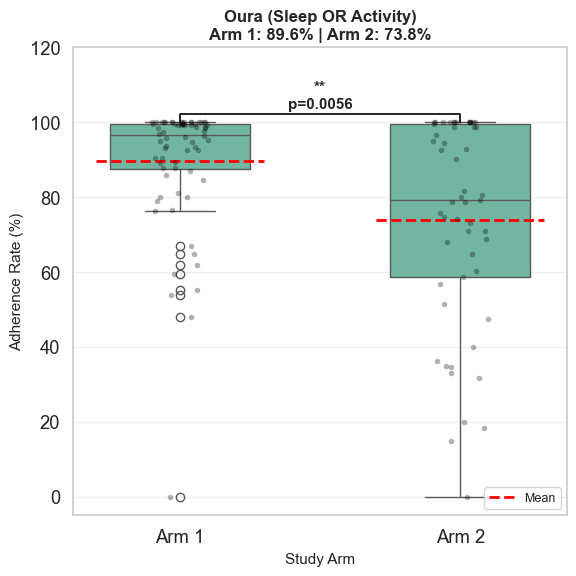

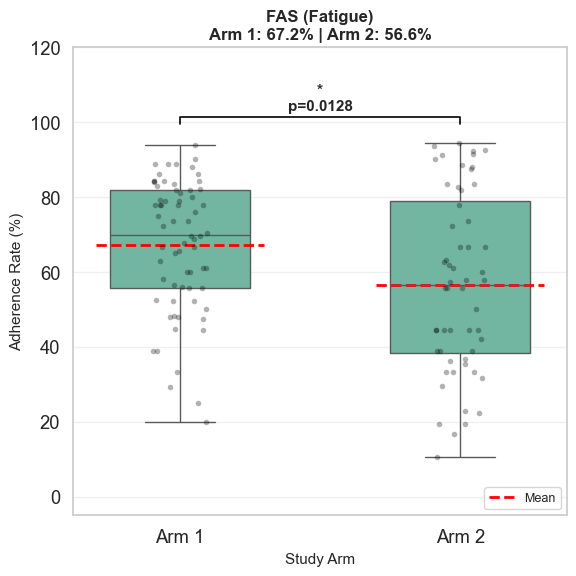

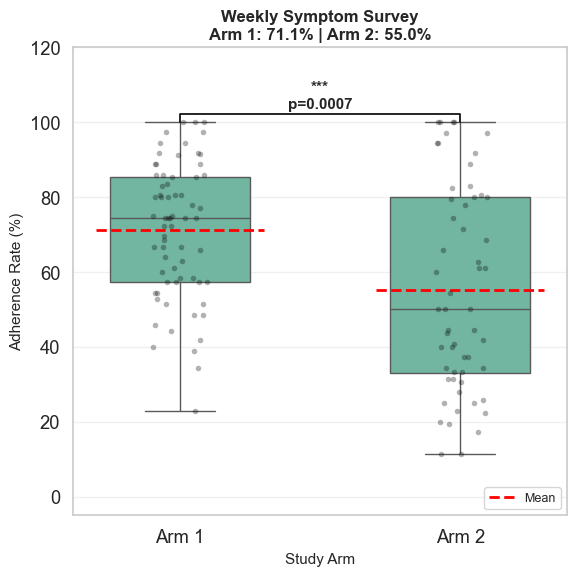

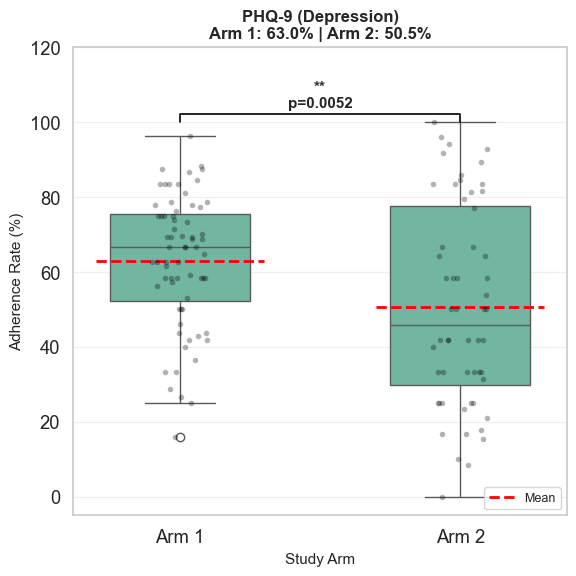

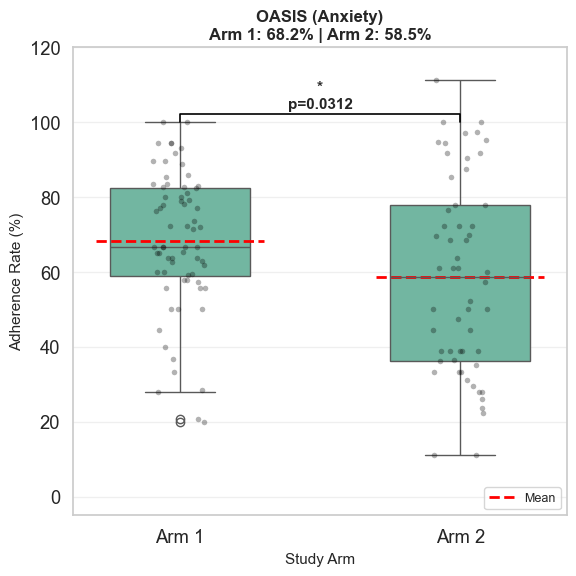

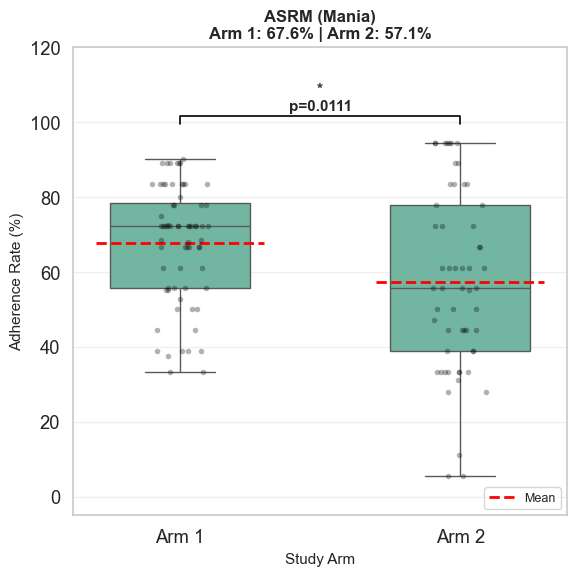

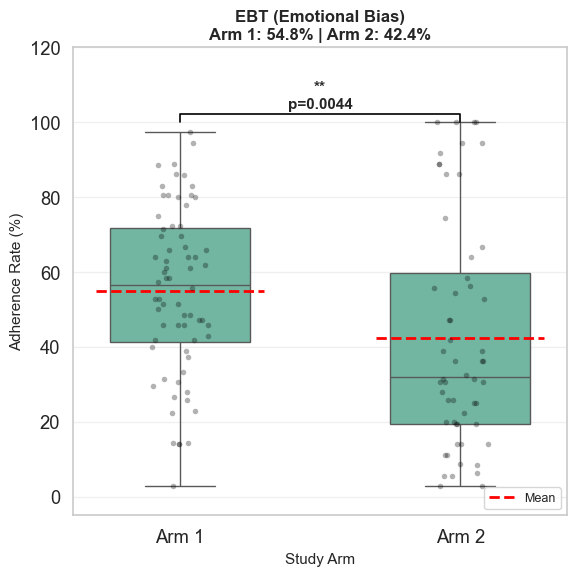

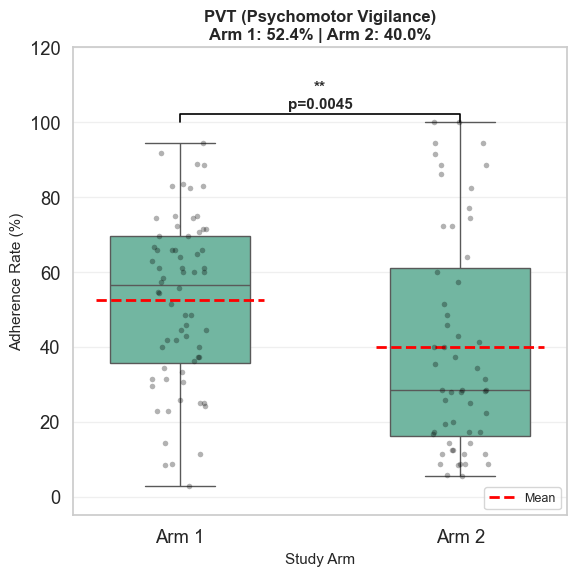

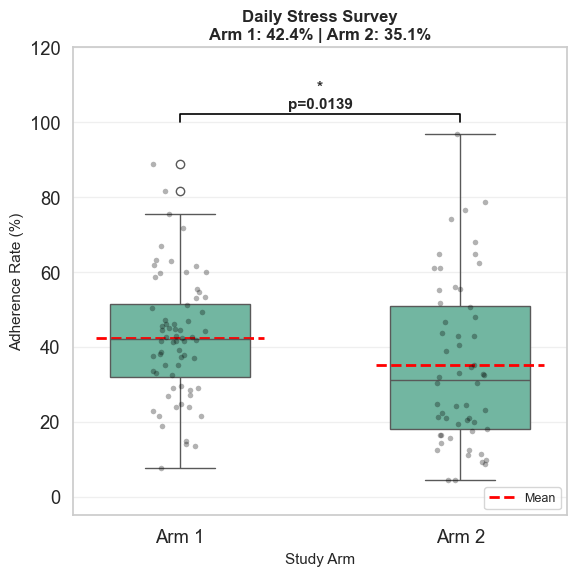

In [57]:
# Visualize adherence comparisons

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def get_sig_str(arm1_data, arm2_data):
    if len(arm1_data) < 2 or len(arm2_data) < 2:
        return ''
    _, p = mannwhitneyu(arm1_data, arm2_data, alternative='two-sided')
    if p < 0.001:
        return f'***\np={p:.4f}'
    elif p < 0.01:
        return f'**\np={p:.4f}'
    elif p < 0.05:
        return f'*\np={p:.4f}'
    else:
        return f'ns\np={p:.4f}'

# Set style
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Get data sources
data_sources = [col for col in adherence_df.columns if col != 'arm']

# Create separate figure for each data source
for data_source in data_sources:
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Prepare data for boxplot
    arm1_data = adherence_df[adherence_df['arm'] == 'Arm 1'][data_source].dropna()
    arm2_data = adherence_df[adherence_df['arm'] == 'Arm 2'][data_source].dropna()
    
    data_for_plot = pd.DataFrame({
        'Adherence (%)': list(arm1_data) + list(arm2_data),
        'Arm': ['Arm 1']*len(arm1_data) + ['Arm 2']*len(arm2_data)
    })
    
    # Create boxplot
    sns.boxplot(data=data_for_plot, x='Arm', y='Adherence (%)', ax=ax, width=0.5)
    sns.stripplot(data=data_for_plot, x='Arm', y='Adherence (%)', ax=ax, 
                  color='black', alpha=0.3, size=4)
    
    # Add mean line
    for i, arm in enumerate(['Arm 1', 'Arm 2']):
        arm_vals = data_for_plot[data_for_plot['Arm'] == arm]['Adherence (%)']
        mean_val = arm_vals.mean()
        ax.hlines(mean_val, i-0.3, i+0.3, colors='red', linestyles='--', 
                  linewidth=2, label='Mean' if i == 0 else '')
    
    # Add significance annotation
    sig = get_sig_str(arm1_data, arm2_data)
    y_max = max(arm1_data.max(), arm2_data.max()) if len(arm1_data) > 0 and len(arm2_data) > 0 else 100
    bracket_y = min(y_max + 5, 100)
    ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + 2, bracket_y + 2, bracket_y],
            color='black', linewidth=1.2)
    ax.text(0.5, bracket_y + 3, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_title(f'{data_source}\nArm 1: {arm1_data.mean():.1f}% | Arm 2: {arm2_data.mean():.1f}%', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Adherence Rate (%)', fontsize=11)
    ax.set_xlabel('Study Arm', fontsize=11)
    ax.set_ylim(-5, 120)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print('\nVisualization complete')
print('*p<0.05; **p<0.01; ***p<0.001')

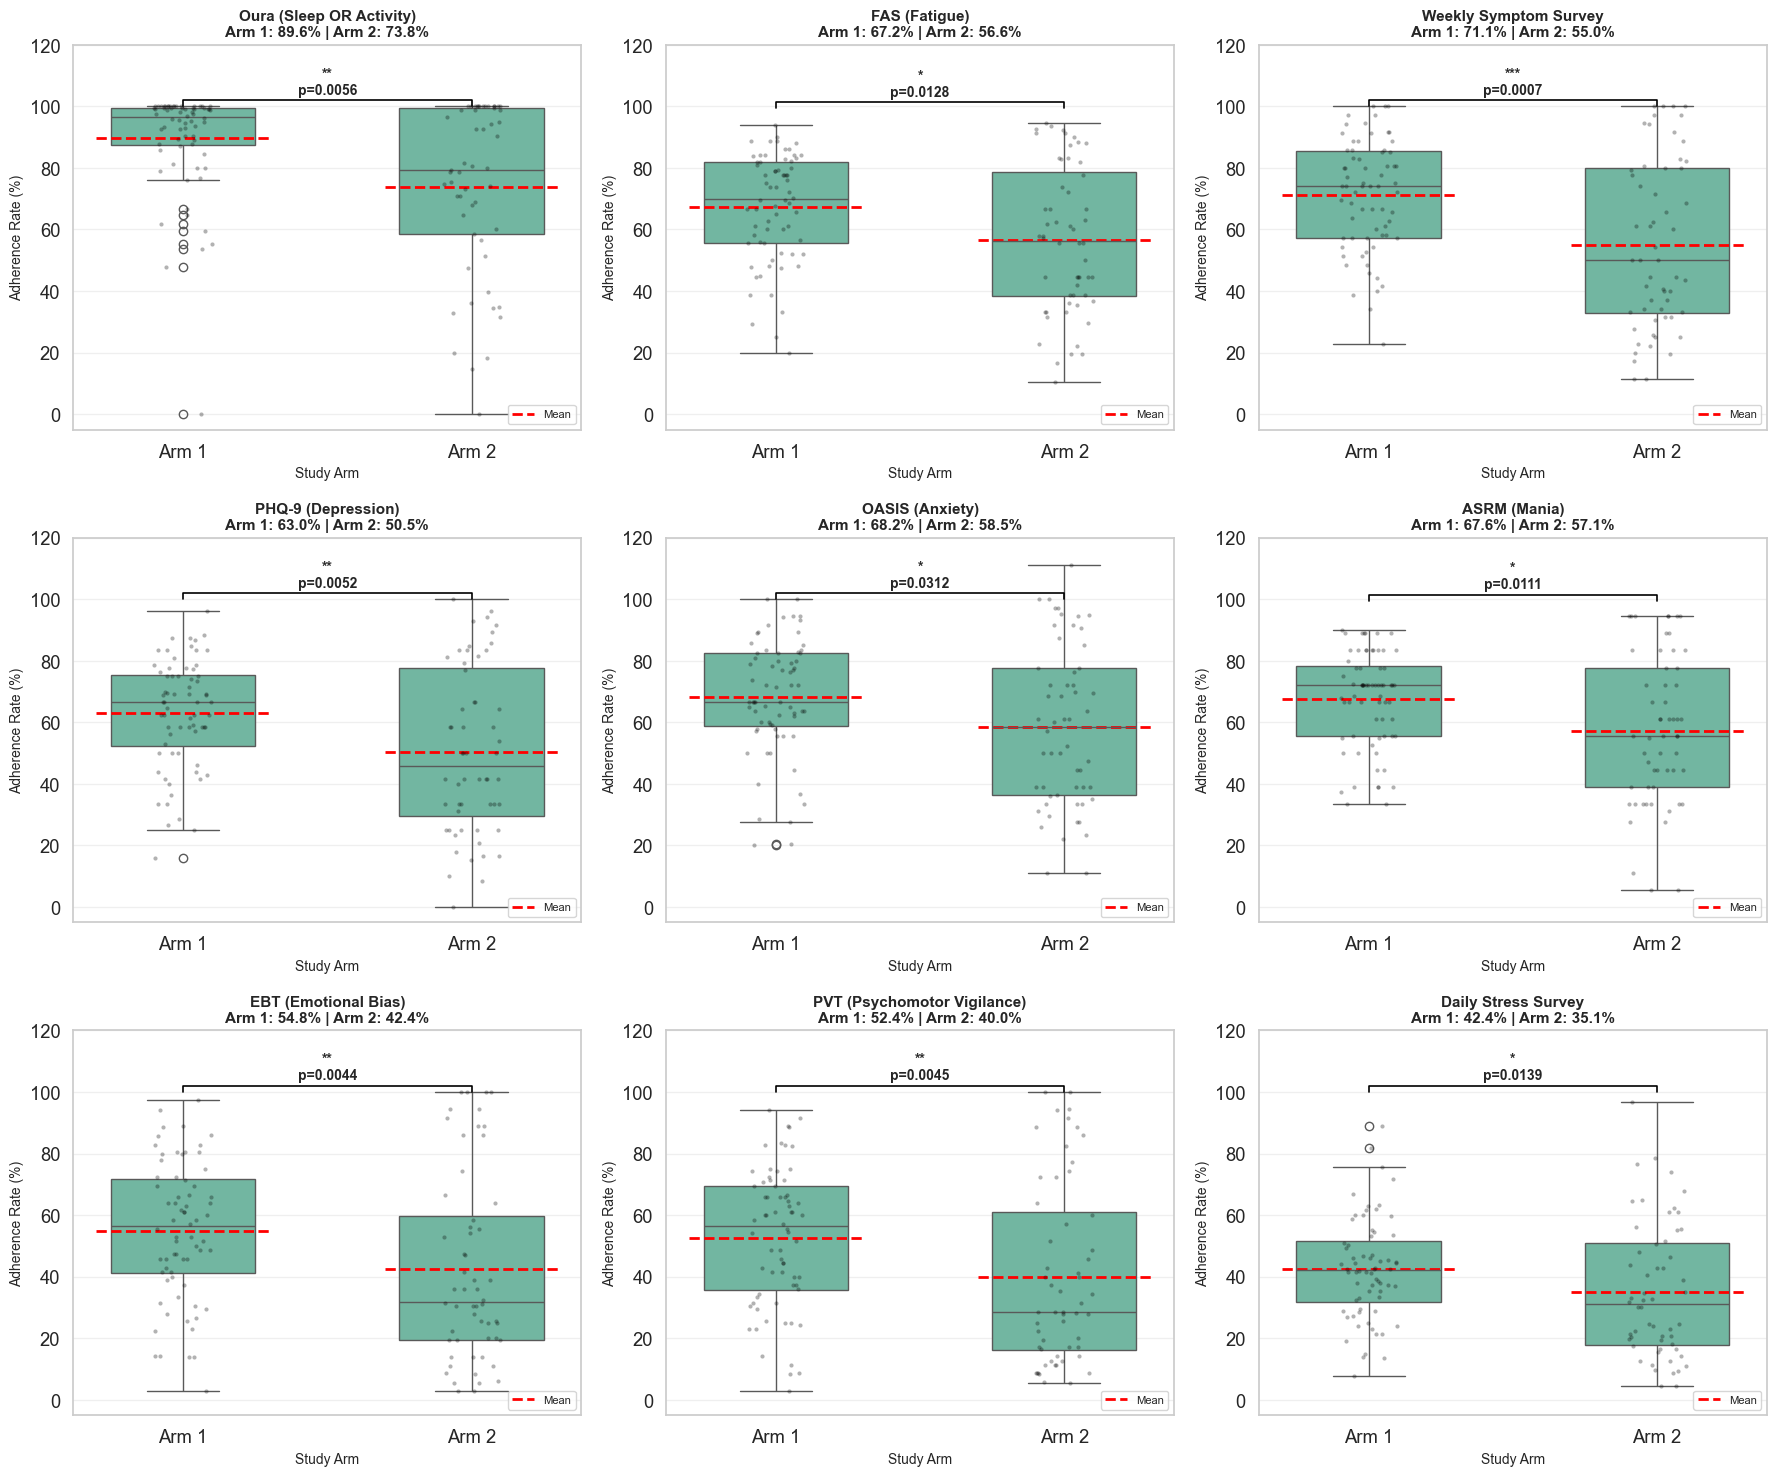

In [58]:
# Panel figure — all adherence boxplots in one figure

import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import mannwhitneyu

def get_sig_str(arm1_data, arm2_data):
    if len(arm1_data) < 2 or len(arm2_data) < 2:
        return ''
    _, p = mannwhitneyu(arm1_data, arm2_data, alternative='two-sided')
    if p < 0.001:
        return f'***\np={p:.4f}'
    elif p < 0.01:
        return f'**\np={p:.4f}'
    elif p < 0.05:
        return f'*\np={p:.4f}'
    else:
        return f'ns\np={p:.4f}'

sns.set_style('whitegrid')
sns.set_palette('Set2')

data_sources = [col for col in adherence_df.columns if col != 'arm']
n = len(data_sources)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for idx, data_source in enumerate(data_sources):
    ax = axes[idx]

    arm1_data = adherence_df[adherence_df['arm'] == 'Arm 1'][data_source].dropna()
    arm2_data = adherence_df[adherence_df['arm'] == 'Arm 2'][data_source].dropna()

    data_for_plot = pd.DataFrame({
        'Adherence (%)': list(arm1_data) + list(arm2_data),
        'Arm': ['Arm 1'] * len(arm1_data) + ['Arm 2'] * len(arm2_data)
    })

    sns.boxplot(data=data_for_plot, x='Arm', y='Adherence (%)', ax=ax, width=0.5)
    sns.stripplot(data=data_for_plot, x='Arm', y='Adherence (%)', ax=ax,
                  color='black', alpha=0.3, size=3)

    # Add mean lines
    for i, arm in enumerate(['Arm 1', 'Arm 2']):
        mean_val = data_for_plot[data_for_plot['Arm'] == arm]['Adherence (%)'].mean()
        ax.hlines(mean_val, i - 0.3, i + 0.3, colors='red', linestyles='--',
                  linewidth=2, label='Mean' if i == 0 else '')

    # Add significance annotation
    sig = get_sig_str(arm1_data, arm2_data)
    y_max = max(arm1_data.max(), arm2_data.max()) if len(arm1_data) > 0 and len(arm2_data) > 0 else 100
    bracket_y = min(y_max + 5, 100)
    ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + 2, bracket_y + 2, bracket_y],
            color='black', linewidth=1.2)
    ax.text(0.5, bracket_y + 3, sig, ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(f'{data_source}\nArm 1: {arm1_data.mean():.1f}% | Arm 2: {arm2_data.mean():.1f}%',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Adherence Rate (%)', fontsize=10)
    ax.set_xlabel('Study Arm', fontsize=10)
    ax.set_ylim(-5, 120)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

# fig.suptitle('Adherence by Study Arm — All Data Sources\n*p<0.05; **p<0.01; ***p<0.001',
#              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Weekly Oura Usage Over Time by Study Arm

In [59]:
# Clean the date columns by removing problematic entries
arm1Demo['Oura Start'] = pd.to_datetime(arm1Demo['Oura Start'].replace('DISCONNECTED FROM APP', pd.NA), errors='coerce')
arm1Demo['4YAM End'] = pd.to_datetime(arm1Demo['4YAM End'].replace('DISCONNECTED FROM APP', pd.NA), errors='coerce')
arm2Demo['Oura Start'] = pd.to_datetime(arm2Demo['Oura Start'].replace('DISCONNECTED FROM APP', pd.NA), errors='coerce')
arm2Demo['4YAM End'] = pd.to_datetime(arm2Demo['4YAM End'].replace('DISCONNECTED FROM APP', pd.NA), errors='coerce')

# Drop rows with NaN dates
arm1Demo_clean = arm1Demo.dropna(subset=['Oura Start', '4YAM End'])
arm2Demo_clean = arm2Demo.dropna(subset=['Oura Start', '4YAM End'])

# Convert the Date column in sleep_data to datetime
df_sleep['Date'] = pd.to_datetime(df_sleep['Date'])

# Function to calculate adherence
def calculate_adherence(row, sleep_data):
    user_data = sleep_data[sleep_data['mm_id'] == row['mm_id']]
    if len(user_data) == 0:
        return 0
        
    start_date = row['Oura Start']
    end_date = row['4YAM End']
    expected_days = (end_date - start_date).days + 1
    
    actual_days = user_data[(user_data['Date'] >= start_date) & 
                           (user_data['Date'] <= end_date)]['Date'].nunique()
    
    return (actual_days / expected_days) * 100 if expected_days > 0 else 0

# Calculate adherence for each arm
arm1_adherence = arm1Demo_clean.apply(lambda row: calculate_adherence(row, df_sleep), axis=1)
arm2_adherence = arm2Demo_clean.apply(lambda row: calculate_adherence(row, df_sleep), axis=1)

# Print summary statistics
print("Arm 1 Adherence:")
print(f"Mean: {arm1_adherence.mean():.2f}%")
print(f"Median: {arm1_adherence.median():.2f}%")
print(f"\nArm 2 Adherence:")
print(f"Mean: {arm2_adherence.mean():.2f}%")
print(f"Median: {arm2_adherence.median():.2f}%")

# Perform statistical testing (Mann-Whitney U test)
from scipy.stats import mannwhitneyu
statistic, p_value = mannwhitneyu(arm1_adherence, arm2_adherence, alternative='two-sided')

print(f"\nMann-Whitney U test:")
print(f"Statistic: {statistic:.2f}")
print(f"p_value: {p_value:.4f}")

<cell>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Arm 1 Adherence:
Mean: 79.44%
Median: 86.72%

Arm 2 Adherence:
Mean: 62.73%
Median: 74.09%

Mann-Whitney U test:
Statistic: 11069.50
p_value: 0.0028


## Data Validation Checks

Confirms that adherence is computed against the correct participant identifier (`UserID` for Oura data), the correct date columns, and each participant's individual enrollment window.

In [60]:
# Data validation checks

print("="*80)
print("DATA VALIDATION CHECKS")
print("="*80)

print("\n1. Identifier column in df_sleep")
print("-" * 80)

# Check if mm_id exists in df_sleep
if 'mm_id' in df_sleep.columns:
    print("df_sleep has 'mm_id' column")
    print(f"  Unique mm_ids in df_sleep: {df_sleep['mm_id'].nunique()}")
elif 'UserID' in df_sleep.columns:
    print("df_sleep is keyed by 'UserID', not 'mm_id'")
    print(f"  Unique UserIDs in df_sleep: {df_sleep['UserID'].nunique()}")
    print("  Participant matching must use 'UserID'.")
    print("  Use sleep_data[sleep_data['UserID'] == ...] for matching.")
else:
    print("Neither 'mm_id' nor 'UserID' found in df_sleep")

print("\n2. Date column in df_sleep")
print("-" * 80)

if 'Date' in df_sleep.columns:
    print("df_sleep has 'Date' column (uppercase)")
elif 'date' in df_sleep.columns:
    print("df_sleep has a 'date' column (lowercase), not 'Date'")
    print("  Reference the column name present in df_sleep.")
    print("  Use the 'date' column where appropriate.")
else:
    date_cols = [col for col in df_sleep.columns if 'date' in col.lower()]
    print(f"No 'Date' or 'date' column. Date-related columns: {date_cols}")

print("\n3. Participant scope")
print("-" * 80)

print(f"arm1Demo (all): {len(arm1Demo)} participants")
print(f"arm1Demo_clean (after dropping NaN): {len(arm1Demo.dropna(subset=['Oura Start', '4YAM End']))} participants")
print(f"arm1Full (STATUS == 'FULL (≥8M)'): {len(arm1Full)} participants")
print(f"\narm2Demo (all): {len(arm2Demo)} participants")
print(f"arm2Demo_clean (after dropping NaN): {len(arm2Demo.dropna(subset=['Oura Start', '4YAM End']))} participants")
print(f"arm2Full (STATUS == 'FULL (≥8M)'): {len(arm2Full)} participants")

print("\narm1Demo/arm2Demo include all enrolled participants")
print("  (dropouts, LTFU, and withdrawn participants).")
print("  Completer-only analyses use arm1Full/arm2Full.")

print("\n4. Data type: sleep only vs sleep OR activity")
print("-" * 80)

print("df_sleep captures nighttime (sleep) data only")
print("Alternative: Oura Any Day = days with EITHER sleep OR activity")
print("  Sleep only might undercount days if participants wore ring during day but not night")

print("\n5. Sample calculation")
print("-" * 80)

# Pick a test participant
if len(arm1Demo) > 0:
    test_participant = arm1Demo.iloc[0].copy()
    test_mm_id = test_participant['mm_id']
    
    print(f"\nTest participant: mm_id {test_mm_id}")
    
    # Try finding data with mm_id
    sleep_by_mmid = df_sleep[df_sleep['mm_id'] == test_mm_id] if 'mm_id' in df_sleep.columns else pd.DataFrame()
    
    # Try finding data with UserID
    sleep_by_userid = df_sleep[df_sleep['UserID'] == test_mm_id] if 'UserID' in df_sleep.columns else pd.DataFrame()
    
    print(f"  Sleep records found using 'mm_id': {len(sleep_by_mmid)}")
    print(f"  Sleep records found using 'UserID': {len(sleep_by_userid)}")
    
    if len(sleep_by_mmid) == 0 and len(sleep_by_userid) > 0:
        print("\n  df_sleep is keyed by 'UserID'; matching uses 'UserID'.")

print("\n" + "="*80)

DATA VALIDATION CHECKS

1. Identifier column in df_sleep
--------------------------------------------------------------------------------
df_sleep has 'mm_id' column
  Unique mm_ids in df_sleep: 262

2. Date column in df_sleep
--------------------------------------------------------------------------------
df_sleep has 'Date' column (uppercase)

3. Participant scope
--------------------------------------------------------------------------------
arm1Demo (all): 151 participants
arm1Demo_clean (after dropping NaN): 144 participants
arm1Full (STATUS == 'FULL (≥8M)'): 68 participants

arm2Demo (all): 151 participants
arm2Demo_clean (after dropping NaN): 127 participants
arm2Full (STATUS == 'FULL (≥8M)'): 56 participants

arm1Demo/arm2Demo include all enrolled participants
  (dropouts, LTFU, and withdrawn participants).
  Completer-only analyses use arm1Full/arm2Full.

4. Data type: sleep only vs sleep OR activity
----------------------------------------------------------------------------

In [61]:
#   1. Uses 'UserID' instead of 'mm_id' to match df_sleep column names
#   2. Properly handles date conversions
#   3. Provides both options: all participants vs full participants only

# First, ensure df_sleep has a properly formatted date column
# The original df_sleep has 'date' (lowercase) created from 'summary_date'
if 'Date' not in df_sleep.columns and 'date' in df_sleep.columns:
    df_sleep['Date'] = pd.to_datetime(df_sleep['date'])
elif 'Date' in df_sleep.columns:
    df_sleep['Date'] = pd.to_datetime(df_sleep['Date'])

# Function to calculate adherence
def calculate_adherence_corrected(row, sleep_data):
    """
    Calculate adherence percentage for a participant.
    
    Matches on 'UserID' to align with df_sleep's identifier column.
    """
    # Match on 'UserID' to align with df_sleep's identifier column
    user_data = sleep_data[sleep_data['UserID'] == row['mm_id']]
    
    if len(user_data) == 0:
        return 0
        
    start_date = pd.to_datetime(row['Oura Start'])
    end_date = pd.to_datetime(row['4YAM End'])
    expected_days = (end_date - start_date).days + 1
    
    # Ensure Date column is datetime for comparison
    user_data_dates = pd.to_datetime(user_data['Date'])
    
    actual_days = user_data[
        (user_data_dates >= start_date) & 
        (user_data_dates <= end_date)
    ]['Date'].nunique()
    
    return (actual_days / expected_days) * 100 if expected_days > 0 else 0

# All participants (including dropouts, LTFU, withdrawn)
print("="*80)
print("Oura sleep adherence - all participants")
print("="*80)

arm1Demo_clean = arm1Demo.dropna(subset=['Oura Start', '4YAM End']).copy()
arm2Demo_clean = arm2Demo.dropna(subset=['Oura Start', '4YAM End']).copy()

arm1_adherence_all = arm1Demo_clean.apply(lambda row: calculate_adherence_corrected(row, df_sleep), axis=1)
arm2_adherence_all = arm2Demo_clean.apply(lambda row: calculate_adherence_corrected(row, df_sleep), axis=1)

print(f"\nArm 1 (Supported):")
print(f"  Mean: {arm1_adherence_all.mean():.2f}%")
print(f"  Median: {arm1_adherence_all.median():.2f}%")
print(f"  SD: {arm1_adherence_all.std():.2f}%")
print(f"  n = {len(arm1_adherence_all)}")

print(f"\nArm 2 (Unsupported):")
print(f"  Mean: {arm2_adherence_all.mean():.2f}%")
print(f"  Median: {arm2_adherence_all.median():.2f}%")
print(f"  SD: {arm2_adherence_all.std():.2f}%")
print(f"  n = {len(arm2_adherence_all)}")

# Mann-Whitney U test
from scipy.stats import mannwhitneyu
stat_all, p_value_all = mannwhitneyu(arm1_adherence_all, arm2_adherence_all, alternative='two-sided')
print(f"\nMann-Whitney U test:")
print(f"  U = {stat_all:.2f}")
print(f"  p = {p_value_all:.4f}")
if p_value_all < 0.05:
    print(f"  *** SIGNIFICANT difference between arms (p < 0.05)")
else:
    print(f"  No significant difference between arms")

# Completers only (STATUS == 'FULL (≥8M)')
print("\n" + "="*80)
print("Oura sleep adherence - completers only (≥8M)")
print("="*80)

arm1Full_clean = arm1Full.dropna(subset=['Oura Start', '4YAM End']).copy()
arm2Full_clean = arm2Full.dropna(subset=['Oura Start', '4YAM End']).copy()

arm1_adherence_full = arm1Full_clean.apply(lambda row: calculate_adherence_corrected(row, df_sleep), axis=1)
arm2_adherence_full = arm2Full_clean.apply(lambda row: calculate_adherence_corrected(row, df_sleep), axis=1)

print(f"\nArm 1 (Supported):")
print(f"  Mean: {arm1_adherence_full.mean():.2f}%")
print(f"  Median: {arm1_adherence_full.median():.2f}%")
print(f"  SD: {arm1_adherence_full.std():.2f}%")
print(f"  n = {len(arm1_adherence_full)}")

print(f"\nArm 2 (Unsupported):")
print(f"  Mean: {arm2_adherence_full.mean():.2f}%")
print(f"  Median: {arm2_adherence_full.median():.2f}%")
print(f"  SD: {arm2_adherence_full.std():.2f}%")
print(f"  n = {len(arm2_adherence_full)}")

stat_full, p_value_full = mannwhitneyu(arm1_adherence_full, arm2_adherence_full, alternative='two-sided')
print(f"\nMann-Whitney U test:")
print(f"  U = {stat_full:.2f}")
print(f"  p = {p_value_full:.4f}")
if p_value_full < 0.05:
    print(f"  *** SIGNIFICANT difference between arms (p < 0.05)")
else:
    print(f"  No significant difference between arms")

print("\n" + "="*80)
print("COMPARISON")
print("="*80)
print("\nEarlier sleep-only estimate (all participants):")
print("  Arm 1: 79.44%, Arm 2: 62.73%, p=0.0028")
print("\nAll participants:")
print(f"  Arm 1: {arm1_adherence_all.mean():.2f}%, Arm 2: {arm2_adherence_all.mean():.2f}%, p={p_value_all:.4f}")
print("\nCompleters only:")
print(f"  Arm 1: {arm1_adherence_full.mean():.2f}%, Arm 2: {arm2_adherence_full.mean():.2f}%, p={p_value_full:.4f}")

print("\n" + "="*80)

Oura sleep adherence - all participants

Arm 1 (Supported):
  Mean: 79.44%
  Median: 86.72%
  SD: 22.28%
  n = 144

Arm 2 (Unsupported):
  Mean: 62.73%
  Median: 74.09%
  SD: 34.57%
  n = 127

Mann-Whitney U test:
  U = 11069.50
  p = 0.0028
  *** SIGNIFICANT difference between arms (p < 0.05)

Oura sleep adherence - completers only (≥8M)

Arm 1 (Supported):
  Mean: 85.78%
  Median: 93.70%
  SD: 18.50%
  n = 68

Arm 2 (Unsupported):
  Mean: 71.34%
  Median: 75.55%
  SD: 28.55%
  n = 53

Mann-Whitney U test:
  U = 2200.00
  p = 0.0377
  *** SIGNIFICANT difference between arms (p < 0.05)

COMPARISON

Earlier sleep-only estimate (all participants):
  Arm 1: 79.44%, Arm 2: 62.73%, p=0.0028

All participants:
  Arm 1: 79.44%, Arm 2: 62.73%, p=0.0028

Completers only:
  Arm 1: 85.78%, Arm 2: 71.34%, p=0.0377



In [62]:

print("="*80)
print("Arm 2 data-availability check")
print("="*80)

print("\n1. Checking arm definitions:")
print("-" * 80)
print(f"arm1Demo exists: {('arm1Demo' in dir())}")
print(f"arm2Demo exists: {('arm2Demo' in dir())}")
print(f"arm1Full exists: {('arm1Full' in dir())}")
print(f"arm2Full exists: {('arm2Full' in dir())}")

if 'arm1Demo' in dir():
    print(f"\narm1Demo shape: {arm1Demo.shape}")
    print(f"arm2Demo shape: {arm2Demo.shape}")
    print(f"arm1Full shape: {arm1Full.shape}")
    print(f"arm2Full shape: {arm2Full.shape}")

print("\n2. Checking for 'Oura Start' and '4YAM End' columns:")
print("-" * 80)
if 'arm1Demo' in dir():
    print(f"arm1Demo columns with 'Oura' or '4YAM': {[col for col in arm1Demo.columns if 'Oura' in col or '4YAM' in col]}")
    print(f"arm2Demo columns with 'Oura' or '4YAM': {[col for col in arm2Demo.columns if 'Oura' in col or '4YAM' in col]}")

print("\n3. Checking how many have valid 'Oura Start' and '4YAM End':")
print("-" * 80)
if 'arm1Demo' in dir():
    arm1_has_oura_start = arm1Demo['Oura Start'].notna().sum() if 'Oura Start' in arm1Demo.columns else 0
    arm1_has_4yam_end = arm1Demo['4YAM End'].notna().sum() if '4YAM End' in arm1Demo.columns else 0
    arm1_has_both = arm1Demo.dropna(subset=['Oura Start', '4YAM End']).shape[0] if 'Oura Start' in arm1Demo.columns and '4YAM End' in arm1Demo.columns else 0
    
    arm2_has_oura_start = arm2Demo['Oura Start'].notna().sum() if 'Oura Start' in arm2Demo.columns else 0
    arm2_has_4yam_end = arm2Demo['4YAM End'].notna().sum() if '4YAM End' in arm2Demo.columns else 0
    arm2_has_both = arm2Demo.dropna(subset=['Oura Start', '4YAM End']).shape[0] if 'Oura Start' in arm2Demo.columns and '4YAM End' in arm2Demo.columns else 0
    
    print(f"Arm 1:")
    print(f"  Total participants: {len(arm1Demo)}")
    print(f"  Have 'Oura Start': {arm1_has_oura_start}")
    print(f"  Have '4YAM End': {arm1_has_4yam_end}")
    print(f"  Have BOTH: {arm1_has_both}")
    
    print(f"\nArm 2:")
    print(f"  Total participants: {len(arm2Demo)}")
    print(f"  Have 'Oura Start': {arm2_has_oura_start}")
    print(f"  Have '4YAM End': {arm2_has_4yam_end}")
    print(f"  Have BOTH: {arm2_has_both}")

print("\n4. Sample of Arm 2 data (first 3 rows, relevant columns):")
print("-" * 80)
if 'arm2Demo' in dir() and len(arm2Demo) > 0:
    relevant_cols = ['mm_id', 'Oura Start', '4YAM End', '4YAM Enroll']
    available_cols = [col for col in relevant_cols if col in arm2Demo.columns]
    print(arm2Demo[available_cols].head(3))
else:
    print("arm2Demo is empty or doesn't exist!")

print("\n5. Checking what date columns exist in arm2Demo:")
print("-" * 80)
if 'arm2Demo' in dir():
    date_cols = [col for col in arm2Demo.columns if any(keyword in col for keyword in ['Date', 'date', 'Start', 'End', 'Enroll'])]
    print(f"Date-related columns in arm2Demo: {date_cols}")

print("\n" + "="*80)

Arm 2 data-availability check

1. Checking arm definitions:
--------------------------------------------------------------------------------
arm1Demo exists: True
arm2Demo exists: True
arm1Full exists: True
arm2Full exists: True

arm1Demo shape: (151, 95)
arm2Demo shape: (151, 86)
arm1Full shape: (68, 95)
arm2Full shape: (56, 86)

2. Checking for 'Oura Start' and '4YAM End' columns:
--------------------------------------------------------------------------------
arm1Demo columns with 'Oura' or '4YAM': ['4YAM Enroll', 'Oura Start', '4YAM End']
arm2Demo columns with 'Oura' or '4YAM': ['4YAM Enroll', 'Oura Start', '4YAM End']

3. Checking how many have valid 'Oura Start' and '4YAM End':
--------------------------------------------------------------------------------
Arm 1:
  Total participants: 151
  Have 'Oura Start': 144
  Have '4YAM End': 151
  Have BOTH: 144

Arm 2:
  Total participants: 151
  Have 'Oura Start': 127
  Have '4YAM End': 151
  Have BOTH: 127

4. Sample of Arm 2 data (fir

## Weekly Oura Adherence: Full Completers (>= 8 Months)

In [63]:
# Filter for participants with STATUS == 'Full (>= 8M)'
arm1Demo_full = arm1Demo[arm1Demo['STATUS'] == 'FULL (≥8M)']
arm2Demo_full = arm2Demo[arm2Demo['STATUS'] == 'FULL (≥8M)']

# Clean the date columns by removing problematic entries
arm1Demo_full['Oura Start'] = pd.to_datetime(arm1Demo_full['Oura Start'].replace('DISCONNECTED FROM APP', pd.NA), errors='coerce')
arm1Demo_full['4YAM End'] = pd.to_datetime(arm1Demo_full['4YAM End'].replace('DISCONNECTED FROM APP', pd.NA), errors='coerce')
arm2Demo_full['Oura Start'] = pd.to_datetime(arm2Demo_full['Oura Start'].replace('DISCONNECTED FROM APP', pd.NA), errors='coerce')
arm2Demo_full['4YAM End'] = pd.to_datetime(arm2Demo_full['4YAM End'].replace('DISCONNECTED FROM APP', pd.NA), errors='coerce')

# Drop rows with NaN dates
arm1Demo_clean_full = arm1Demo_full.dropna(subset=['Oura Start', '4YAM End'])
arm2Demo_clean_full = arm2Demo_full.dropna(subset=['Oura Start', '4YAM End'])

# Convert the Date column in sleep_data to datetime
df_sleep['Date'] = pd.to_datetime(df_sleep['Date'])

# Function to calculate adherence
def calculate_adherence(row, sleep_data):
    user_data = sleep_data[sleep_data['mm_id'] == row['mm_id']]
    if len(user_data) == 0:
        return 0
        
    start_date = row['Oura Start']
    end_date = row['4YAM End']
    expected_days = (end_date - start_date).days + 1
    
    actual_days = user_data[(user_data['Date'] >= start_date) & 
                           (user_data['Date'] <= end_date)]['Date'].nunique()
    
    return (actual_days / expected_days) * 100 if expected_days > 0 else 0

# Calculate adherence for each arm
arm1_adherence_full = arm1Demo_clean_full.apply(lambda row: calculate_adherence(row, df_sleep), axis=1)
arm2_adherence_full = arm2Demo_clean_full.apply(lambda row: calculate_adherence(row, df_sleep), axis=1)

# Print summary statistics
print("Arm 1 Adherence (Full >= 8M):")
print(f"Mean: {arm1_adherence_full.mean():.2f}%")
print(f"Median: {arm1_adherence_full.median():.2f}%")
print(f"\nArm 2 Adherence (Full >= 8M):")
print(f"Mean: {arm2_adherence_full.mean():.2f}%")
print(f"Median: {arm2_adherence_full.median():.2f}%")

# Perform statistical testing (Mann-Whitney U test)
from scipy.stats import mannwhitneyu
statistic, p_value = mannwhitneyu(arm1_adherence_full, arm2_adherence_full, alternative='two-sided')

print(f"\nMann-Whitney U test (Full >= 8M):")
print(f"Statistic: {statistic:.2f}")
print(f"p_value: {p_value:.4f}")

Arm 1 Adherence (Full >= 8M):
Mean: 85.78%
Median: 93.70%

Arm 2 Adherence (Full >= 8M):
Mean: 71.34%
Median: 75.55%

Mann-Whitney U test (Full >= 8M):
Statistic: 2200.00
p_value: 0.0377



Number of participants per week (Full Participation Only):
arm   Arm 1  Arm 2
week              
1        68     53
2        68     53
3        68     53
4        68     53
5        68     53
6        68     53
7        68     53
8        68     53
9        68     53
10       68     53
11       68     53
12       68     53
13       68     53
14       68     53
15       68     53
16       68     53
17       68     53
18       68     53
19       68     53
20       68     53
21       68     53
22       68     52
23       68     52
24       68     52
25       68     52
26       68     52
27       68     52
28       68     52
29       67     52
30       65     51
31       62     51
32       60     47
33       50     40
34       28     24
35        9      3
36        2      1


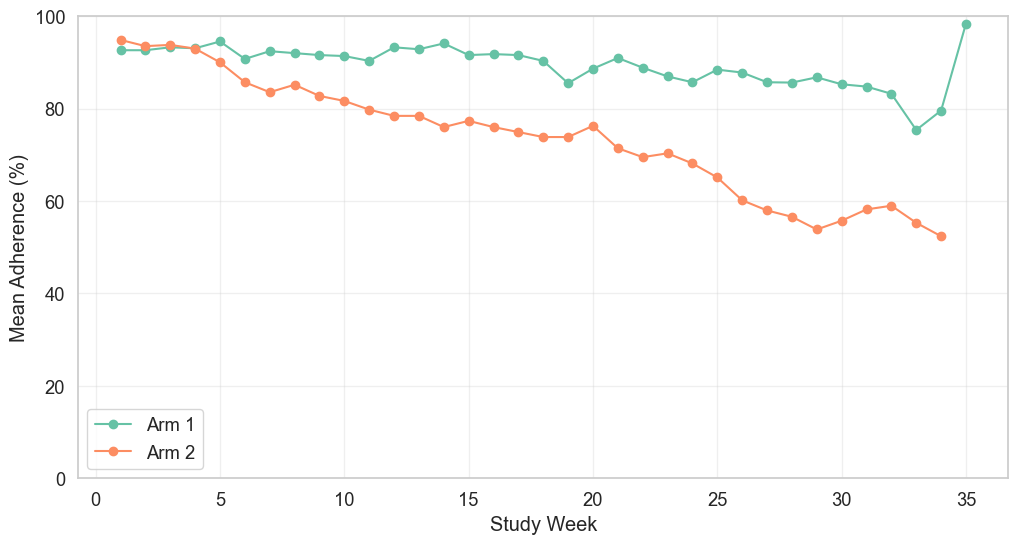

In [64]:
# Create function to calculate weekly adherence using combined Oura data (Sleep OR Activity)
def calculate_weekly_adherence(df_sleep, df_activity, metadata):
    # Ensure Date columns are datetime
    df_sleep = df_sleep.copy()
    df_activity = df_activity.copy()
    df_sleep['Date'] = pd.to_datetime(df_sleep['Date'])
    df_activity['Date'] = pd.to_datetime(df_activity['Date'])
    
    weekly_adherence = []
    
    for _, row in metadata.iterrows():
        user_sleep = df_sleep[df_sleep['mm_id'] == row['MindMed ID']]
        user_activity = df_activity[df_activity['mm_id'] == row['MindMed ID']]
        start_date = row['Oura Start']
        end_date = row['4YAM End']
        
        # Generate week ranges
        weeks = pd.date_range(start=start_date, end=end_date, freq='W')
        for week_num, week_start in enumerate(weeks, 1):
            week_end = week_start + pd.Timedelta(days=6)
            
            # Get sleep days in this week
            week_sleep = user_sleep[(user_sleep['Date'] >= week_start) & 
                                   (user_sleep['Date'] <= week_end)]
            sleep_days = set(week_sleep['Date'].dt.date)
            
            # Get activity days in this week
            week_activity = user_activity[(user_activity['Date'] >= week_start) & 
                                         (user_activity['Date'] <= week_end)]
            activity_days = set(week_activity['Date'].dt.date)
            
            # Union: days with EITHER sleep OR activity
            valid_days = len(sleep_days.union(activity_days))
            
            # Calculate expected days (handle partial weeks)
            expected_days = 7
            if week_start < start_date:
                days_before = (start_date - week_start).days
                expected_days -= days_before
            if week_end > end_date:
                days_after = (week_end - end_date).days
                expected_days -= days_after
                
            adherence_pct = (valid_days / expected_days) * 100 if expected_days > 0 else 0
            
            weekly_adherence.append({
                'mm_id': row['MindMed ID'],
                'week': week_num,
                'arm': row['arm'],
                'valid_days': valid_days,
                'expected_days': expected_days,
                'adherence_pct': adherence_pct
            })
    
    return pd.DataFrame(weekly_adherence)

# Create metadata DataFrame with arm information for full participation only
metadata_full = pd.DataFrame({
    'MindMed ID': pd.concat([arm1Demo_clean_full['mm_id'], arm2Demo_clean_full['mm_id']]),
    'Oura Start': pd.concat([arm1Demo_clean_full['Oura Start'], arm2Demo_clean_full['Oura Start']]),
    '4YAM End': pd.concat([arm1Demo_clean_full['4YAM End'], arm2Demo_clean_full['4YAM End']]),
    'arm': ['Arm 1'] * len(arm1Demo_clean_full) + ['Arm 2'] * len(arm2Demo_clean_full)
})

# Calculate weekly adherence using combined Oura data
weekly_adherence_full = calculate_weekly_adherence(df_sleep, df_activity, metadata_full)

# Count participants per week and arm
participant_counts_full = weekly_adherence_full.groupby(['arm', 'week'])['mm_id'].nunique().reset_index()

# Get weeks with at least 5 participants for each arm
valid_weeks_full = participant_counts_full[participant_counts_full['mm_id'] >= 5][['arm', 'week']]

# Calculate mean adherence by week and arm
summary_full = weekly_adherence_full.groupby(['arm', 'week'])['adherence_pct'].mean().reset_index()

# Filter summary to include only weeks with sufficient participants
summary_full = summary_full.merge(valid_weeks_full, on=['arm', 'week'])

# Plot
plt.figure(figsize=(12, 6))
for arm in ['Arm 1', 'Arm 2']:
    arm_data = summary_full[summary_full['arm'] == arm]
    plt.plot(arm_data['week'], arm_data['adherence_pct'], label=arm, marker='o')

plt.xlabel('Study Week')
plt.ylabel('Mean Adherence (%)')
# plt.title('Weekly Oura Ring Adherence by Study Arm (Full Participation Only)\n'
#           '(Sleep OR Activity, Weeks with >= 5 Participants)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.show()

# Print the number of participants per week
print('\nNumber of participants per week (Full Participation Only):')
print(participant_counts_full.pivot(index='week', columns='arm', values='mm_id').fillna(0).astype(int))

## Temporal Trends in Weekly Adherence

Tests whether weekly Oura adherence changes over the study period, by arm.

In [65]:
# Linear regression for temporal trends in adherence
# Tests whether adherence changes linearly over time (weeks)

import statsmodels.api as sm
from scipy.stats import spearmanr

print("="*80)
print("TEMPORAL TREND ANALYSIS: Does adherence change over time?")
print("="*80)

# Analyze each arm separately
for arm_name in ['Arm 1', 'Arm 2']:
    print(f"\n{'='*80}")
    print(f"{arm_name.upper()}")
    print(f"{'='*80}")
    
    # Get data for this arm
    arm_data = weekly_adherence_full[weekly_adherence_full['arm'] == arm_name].copy()
    
    if len(arm_data) == 0:
        print(f"  No data available for {arm_name}")
        continue
    
    # Simple linear regression: adherence ~ week
    X = arm_data['week'].values
    y = arm_data['adherence_pct'].values
    
    # Add constant for intercept
    X_with_const = sm.add_constant(X)
    
    # Fit OLS model
    model = sm.OLS(y, X_with_const)
    results = model.fit()
    
    print(f"\nLinear Regression: Weekly Adherence ~ Study Week")
    print(f"  Sample size: {len(arm_data)} participant-weeks")
    print(f"  Unique participants: {arm_data['mm_id'].nunique()}")
    print(f"  Week range: {X.min():.0f} to {X.max():.0f}")
    print(f"\n  Intercept: {results.params[0]:.2f}%")
    print(f"  Slope (change per week): {results.params[1]:.3f}% per week")
    print(f"  R-squared: {results.rsquared:.4f}")
    print(f"  p-value for slope: {results.pvalues[1]:.4f}")
    
    if results.pvalues[1] < 0.05:
        trend = "decreasing" if results.params[1] < 0 else "increasing"
        print(f"\n  *** SIGNIFICANT {trend.upper()} trend over time (p < 0.05) ***")
    else:
        print(f"\n  No significant linear trend over time (p ≥ 0.05)")
    
    # Spearman correlation (non-parametric alternative)
    rho, p_spearman = spearmanr(X, y)
    print(f"\nSpearman Correlation (non-parametric):")
    print(f"  Correlation coefficient (ρ): {rho:.4f}")
    print(f"  p-value: {p_spearman:.4f}")
    
    if p_spearman < 0.05:
        direction = "negative" if rho < 0 else "positive"
        print(f"  *** SIGNIFICANT {direction} correlation (p < 0.05) ***")

print("\n" + "="*80)

TEMPORAL TREND ANALYSIS: Does adherence change over time?

ARM 1

Linear Regression: Weekly Adherence ~ Study Week
  Sample size: 2247 participant-weeks
  Unique participants: 68
  Week range: 1 to 36

  Intercept: 95.06%
  Slope (change per week): -0.327% per week
  R-squared: 0.0131
  p-value for slope: 0.0000

  *** SIGNIFICANT DECREASING trend over time (p < 0.05) ***

Spearman Correlation (non-parametric):
  Correlation coefficient (ρ): -0.1252
  p-value: 0.0000
  *** SIGNIFICANT negative correlation (p < 0.05) ***

ARM 2

Linear Regression: Weekly Adherence ~ Study Week
  Sample size: 1746 participant-weeks
  Unique participants: 53
  Week range: 1 to 36

  Intercept: 95.71%
  Slope (change per week): -1.267% per week
  R-squared: 0.0808
  p-value for slope: 0.0000

  *** SIGNIFICANT DECREASING trend over time (p < 0.05) ***

Spearman Correlation (non-parametric):
  Correlation coefficient (ρ): -0.2856
  p-value: 0.0000
  *** SIGNIFICANT negative correlation (p < 0.05) ***



In [66]:
weekly_adherence_full

      mm_id  week    arm  valid_days  expected_days  adherence_pct
0        18     1  Arm 1           7              7          100.0
1        18     2  Arm 1           7              7          100.0
2        18     3  Arm 1           7              7          100.0
3        18     4  Arm 1           7              7          100.0
4        18     5  Arm 1           7              7          100.0
...     ...   ...    ...         ...            ...            ...
3988    565    30  Arm 2           7              7          100.0
3989    565    31  Arm 2           7              7          100.0
3990    565    32  Arm 2           7              7          100.0
3991    565    33  Arm 2           7              7          100.0
3992    565    34  Arm 2           2              2          100.0

[3993 rows x 6 columns]

## Longitudinal Model: GEE

In [67]:
# Longitudinal Adherence: GEE (repeated weekly measures within participant)
# Specification:
# Linear (Gaussian) GEE on adherence_pct
# Exchangeable working correlation
# Robust (sandwich) standard errors
# Arm contrasts reported at anchor weeks (4, 12, 24) for interpretability,
#     in addition to the average-week contrast from the centered-week parameterization.

import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Gaussian
from statsmodels.genmod.cov_struct import Exchangeable

print("=" * 80)
print("GEE MODEL: Weekly Oura adherence over time, by arm (FULL participation only)")
print("=" * 80)

# Prepare data
df = weekly_adherence_full.copy()
df = df.sort_values(["mm_id", "week"]).reset_index(drop=True)

# Arm coding: Arm 1 = 0 (reference), Arm 2 = 1
df["arm_numeric"] = (df["arm"] == "Arm 2").astype(int)

# Center week so the arm main effect is interpretable at the average study week
mean_week = df["week"].mean()
df["week_c"] = df["week"] - mean_week
df["week_x_arm"] = df["week_c"] * df["arm_numeric"]

print(f"\nN observations: {len(df)}  |  N participants: {df['mm_id'].nunique()}")
print(df.groupby("arm").agg(n_part=("mm_id", "nunique"),
                            n_obs=("mm_id", "size"),
                            mean_adh=("adherence_pct", "mean")).round(2))

# GEE: Gaussian, exchangeable, robust SEs
model = GEE.from_formula(
    "adherence_pct ~ week_c + arm_numeric + week_x_arm",
    groups="mm_id",
    data=df,
    cov_struct=Exchangeable(),
    family=Gaussian(),
)
result = model.fit()

print("\n" + "=" * 80)
print("GEE  |  Gaussian  |  Exchangeable  |  Robust SEs")
print("=" * 80)
print(result.summary())

# Coefficients
print("\n--- Coefficients (pp scale) ---")
ci = result.conf_int()
for p in ["Intercept", "week_c", "arm_numeric", "week_x_arm"]:
    b, se, pv = result.params[p], result.bse[p], result.pvalues[p]
    lo, hi = ci.loc[p]
    print(f"  {p:<12} beta={b:+.4f}  SE={se:.4f}  p={pv:.4g}  95%CI=[{lo:+.3f}, {hi:+.3f}]")

slope_arm1 = result.params["week_c"]
slope_arm2 = result.params["week_c"] + result.params["week_x_arm"]
print(f"\n  Arm 1 slope: {slope_arm1:+.3f} pp/week")
print(f"  Arm 2 slope: {slope_arm2:+.3f} pp/week")
print(f"  Difference in slopes (Arm 2 - Arm 1): {result.params['week_x_arm']:+.3f} pp/week  "
      f"(p = {result.pvalues['week_x_arm']:.4g})")

# Arm contrast at anchor weeks (delta method on the linear combination)
V = result.cov_params().values
idx = {n: i for i, n in enumerate(result.params.index)}

print("\n--- Model-implied adherence (%) and arm contrast (Arm 2 - Arm 1) at anchor weeks ---")
print(f"{'Week':>5} | {'Arm 1 %':>8} | {'Arm 2 %':>8} | {'Diff pp':>9} | {'95% CI':>18} | {'p':>8}")
for w in [4, 12, 24]:
    wc = w - mean_week
    # Fitted means
    eta1 = (result.params["Intercept"] + result.params["week_c"] * wc)
    eta2 = eta1 + result.params["arm_numeric"] + result.params["week_x_arm"] * wc
    # Contrast vector for (Arm 2 - Arm 1) at week w
    c = np.zeros(len(result.params))
    c[idx["arm_numeric"]] = 1.0
    c[idx["week_x_arm"]] = wc
    est = float(c @ result.params.values)
    se  = float(np.sqrt(c @ V @ c))
    pv = 2 * (1 - norm.cdf(abs(est / se)))
    lo, hi = est - 1.96 * se, est + 1.96 * se
    print(f"{w:>5d} | {eta1:>7.2f}% | {eta2:>7.2f}% | {est:>+8.2f} | [{lo:+6.2f}, {hi:+6.2f}] | {pv:>8.4g}")

# Arm contrast at the average study week (main effect in the centered model)
b_arm, p_arm = result.params["arm_numeric"], result.pvalues["arm_numeric"]
lo_arm, hi_arm = ci.loc["arm_numeric"]
print(f"\n  At the average study week (week {mean_week:.1f}):")
print(f"    Arm 2 - Arm 1 = {b_arm:+.2f} pp, 95% CI [{lo_arm:+.2f}, {hi_arm:+.2f}], p = {p_arm:.4g}")

print("\n" + "=" * 80)

GEE MODEL: Weekly Oura adherence over time, by arm (FULL participation only)

N observations: 3993  |  N participants: 121
       n_part  n_obs  mean_adh
arm                           
Arm 1      68   2247     89.48
Arm 2      53   1746     74.13

GEE  |  Gaussian  |  Exchangeable  |  Robust SEs
                               GEE Regression Results                              
Dep. Variable:               adherence_pct   No. Observations:                 3993
Model:                                 GEE   No. clusters:                      121
Method:                        Generalized   Min. cluster size:                  21
                      Estimating Equations   Max. cluster size:                  36
Family:                           Gaussian   Mean cluster size:                33.0
Dependence structure:         Exchangeable   Num. iterations:                     5
Date:                     Wed, 24 Jun 2026   Scale:                        1153.250
Covariance type:               

Temporal trend visualization saved as 'temporal_trends_adherence.png'


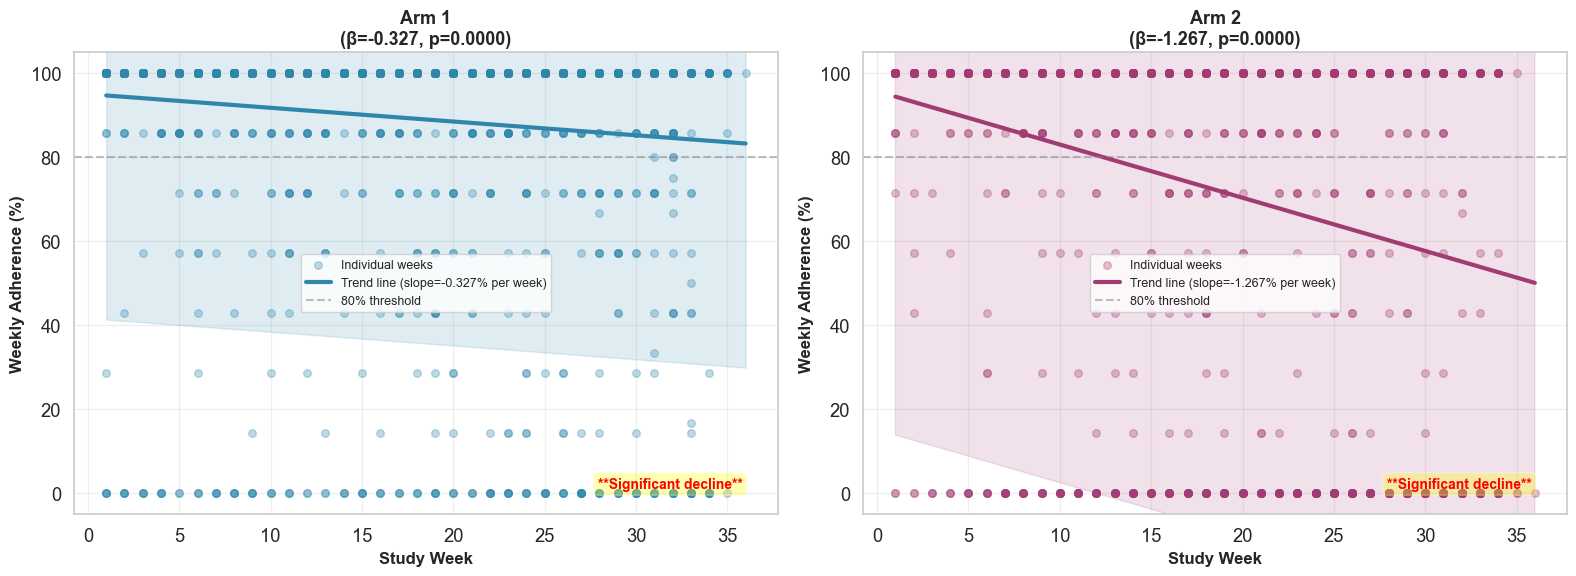

In [68]:
# Visualize temporal trends with regression lines

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'Arm 1': '#2E86AB', 'Arm 2': '#A23B72'}

for idx, arm_name in enumerate(['Arm 1', 'Arm 2']):
    ax = axes[idx]
    
    # Get data for this arm
    arm_data = weekly_adherence_full[weekly_adherence_full['arm'] == arm_name].copy()
    
    if len(arm_data) == 0:
        ax.text(0.5, 0.5, f'No data for {arm_name}', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Scatter plot of individual participant-weeks
    ax.scatter(arm_data['week'], arm_data['adherence_pct'], 
               alpha=0.3, s=30, color=colors[arm_name], label='Individual weeks')
    
    # Calculate and plot regression line
    X = arm_data['week'].values
    y = arm_data['adherence_pct'].values
    
    # Fit regression
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const)
    results = model.fit()
    
    # Plot regression line
    x_range = np.linspace(X.min(), X.max(), 100)
    y_pred = results.params[0] + results.params[1] * x_range
    
    ax.plot(x_range, y_pred, color=colors[arm_name], linewidth=3, 
            label=f'Trend line (slope={results.params[1]:.3f}% per week)')
    
    # Add confidence interval
    predictions = results.get_prediction(sm.add_constant(x_range))
    pred_summary = predictions.summary_frame(alpha=0.05)
    ax.fill_between(x_range, pred_summary['obs_ci_lower'], pred_summary['obs_ci_upper'],
                     alpha=0.15, color=colors[arm_name])
    
    # Add reference line at 80%
    ax.axhline(y=80, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='80% threshold')
    
    # Formatting
    ax.set_xlabel('Study Week', fontsize=12, fontweight='bold')
    ax.set_ylabel('Weekly Adherence (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{arm_name}\n(β={results.params[1]:.3f}, p={results.pvalues[1]:.4f})', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)
    
    # Add significance indicator
    if results.pvalues[1] < 0.05:
        trend_text = "Significant decline" if results.params[1] < 0 else "Significant increase"
        ax.text(0.95, 0.05, f'**{trend_text}**', 
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=10, fontweight='bold', color='red',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('temporal_trends_adherence.png', dpi=300, bbox_inches='tight')
plt.show()

print("Temporal trend visualization saved as 'temporal_trends_adherence.png'")

In [69]:
weekly_adherence_full

      mm_id  week    arm  valid_days  expected_days  adherence_pct
0        18     1  Arm 1           7              7          100.0
1        18     2  Arm 1           7              7          100.0
2        18     3  Arm 1           7              7          100.0
3        18     4  Arm 1           7              7          100.0
4        18     5  Arm 1           7              7          100.0
...     ...   ...    ...         ...            ...            ...
3988    565    30  Arm 2           7              7          100.0
3989    565    31  Arm 2           7              7          100.0
3990    565    32  Arm 2           7              7          100.0
3991    565    33  Arm 2           7              7          100.0
3992    565    34  Arm 2           2              2          100.0

[3993 rows x 6 columns]

In [70]:
# Summary table of temporal trend analyses

print("="*80)
print("SUMMARY TABLE: Temporal Trend Analysis Results")
print("="*80)

summary_results = []

for arm_name in ['Arm 1', 'Arm 2']:
    arm_data = weekly_adherence_full[weekly_adherence_full['arm'] == arm_name].copy()
    
    if len(arm_data) == 0:
        continue
    
    X = arm_data['week'].values
    y = arm_data['adherence_pct'].values
    
    # Linear regression
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const)
    results = model.fit()
    
    # Spearman correlation
    rho, p_spearman = spearmanr(X, y)
    
    # Calculate adherence at week 1 and last week
    week_1_adh = results.params[0] + results.params[1] * 1
    last_week = X.max()
    last_week_adh = results.params[0] + results.params[1] * last_week
    total_change = last_week_adh - week_1_adh
    
    summary_results.append({
        'Arm': arm_name,
        'N participants': arm_data['mm_id'].nunique(),
        'N obs': len(arm_data),
        'Weeks': f"{X.min():.0f}-{X.max():.0f}",
        'Baseline (Week 1)': f"{week_1_adh:.1f}%",
        'Final Week': f"{last_week_adh:.1f}%",
        'Total Change': f"{total_change:.1f}%",
        'Slope (β)': f"{results.params[1]:.3f}",
        'p-value': f"{results.pvalues[1]:.4f}",
        'R²': f"{results.rsquared:.4f}",
        'Spearman ρ': f"{rho:.4f}",
        'Significant': '***' if results.pvalues[1] < 0.001 else ('**' if results.pvalues[1] < 0.01 else ('*' if results.pvalues[1] < 0.05 else ''))
    })

summary_df = pd.DataFrame(summary_results)

print("\n")
print(summary_df.to_string(index=False))
print("\n* p < 0.05, ** p < 0.01, *** p < 0.001")

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

for _, row in summary_df.iterrows():
    arm = row['Arm']
    slope = float(row['Slope (β)'])
    p_val = float(row['p-value'])
    total_change = float(row['Total Change'].rstrip('%'))
    
    print(f"\n{arm}:")
    if p_val < 0.05:
        trend = "declined" if slope < 0 else "improved"
        print(f"  - Adherence significantly {trend} over time (p = {p_val:.4f})")
        print(f"  - Rate of change: {slope:.3f}% per week")
        print(f"  - Total change over study period: {total_change:.1f}%")
    else:
        print(f"  - No significant temporal trend (p = {p_val:.4f})")
        print(f"  - Adherence remained relatively stable throughout the study")

print("\n" + "="*80)

SUMMARY TABLE: Temporal Trend Analysis Results


  Arm  N participants  N obs Weeks Baseline (Week 1) Final Week Total Change Slope (β) p-value     R² Spearman ρ Significant
Arm 1              68   2247  1-36             94.7%      83.3%       -11.4%    -0.327  0.0000 0.0131    -0.1252         ***
Arm 2              53   1746  1-36             94.4%      50.1%       -44.4%    -1.267  0.0000 0.0808    -0.2856         ***

* p < 0.05, ** p < 0.01, *** p < 0.001

KEY FINDINGS:

Arm 1:
  - Adherence significantly declined over time (p = 0.0000)
  - Rate of change: -0.327% per week
  - Total change over study period: -11.4%

Arm 2:
  - Adherence significantly declined over time (p = 0.0000)
  - Rate of change: -1.267% per week
  - Total change over study period: -44.4%



## Notes on the Temporal-Trend Models

Three complementary views of the weekly-adherence trajectory:

- **Linear regression (OLS)** per arm - slope = mean percentage-point change in adherence per study week.
- **Spearman correlation** per arm - monotonic, non-parametric association between study week and adherence.
- **GEE (Gaussian, exchangeable working correlation, robust SEs)** - accounts for repeated weekly measures within participant and estimates the arm main effect and the week x arm interaction.

## Check: Individual Enrollment Windows

Confirms that each participant's adherence denominator uses that participant's own start and end dates.

In [71]:
# Show individual enrollment windows for sample participants

print("="*80)
print("VERIFICATION: Individual Start/End Dates for Sample Participants")
print("="*80)

# Sample 5 participants from each arm
sample_arm1 = arm1Full.head(5)[['mm_id', 'Oura Start', '4YAM Enroll', '4YAM End']]
sample_arm2 = arm2Full.head(5)[['mm_id', 'Oura Start', '4YAM Enroll', '4YAM End']]

print("\nArm 1 Sample:")
for idx, row in sample_arm1.iterrows():
    oura_start = pd.to_datetime(row['Oura Start'])
    enroll_start = pd.to_datetime(row['4YAM Enroll'])
    end = pd.to_datetime(row['4YAM End'])
    
    oura_days = (end - oura_start).days + 1 if pd.notna(oura_start) else 'N/A'
    enroll_days = (end - enroll_start).days + 1
    
    print(f"\n  mm_id {row['mm_id']}:")
    print(f"    Oura: {oura_start.date() if pd.notna(oura_start) else 'N/A'} to {end.date()} = {oura_days} days")
    print(f"    4YAM: {enroll_start.date()} to {end.date()} = {enroll_days} days")

print("\n" + "-"*80)
print("Arm 2 Sample:")
for idx, row in sample_arm2.iterrows():
    oura_start = pd.to_datetime(row['Oura Start'])
    enroll_start = pd.to_datetime(row['4YAM Enroll'])
    end = pd.to_datetime(row['4YAM End'])
    
    oura_days = (end - oura_start).days + 1 if pd.notna(oura_start) else 'N/A'
    enroll_days = (end - enroll_start).days + 1
    
    print(f"\n  mm_id {row['mm_id']}:")
    print(f"    Oura: {oura_start.date() if pd.notna(oura_start) else 'N/A'} to {end.date()} = {oura_days} days")
    print(f"    4YAM: {enroll_start.date()} to {end.date()} = {enroll_days} days")

print("\n" + "="*80)
print("Each participant has their own individual start and end dates")
print("Oura data uses 'Oura Start' to '4YAM End'")
print("Questionnaire data uses '4YAM Enroll' to '4YAM End'")
print("="*80)

VERIFICATION: Individual Start/End Dates for Sample Participants

Arm 1 Sample:

  mm_id 18:
    Oura: 2023-07-08 to 2024-03-15 = 252 days
    4YAM: 2023-07-08 to 2024-03-15 = 252 days

  mm_id 23:
    Oura: 2023-08-26 to 2024-04-17 = 236 days
    4YAM: 2023-08-14 to 2024-04-17 = 248 days

  mm_id 24:
    Oura: 2023-08-27 to 2024-04-20 = 238 days
    4YAM: 2023-08-16 to 2024-04-20 = 249 days

  mm_id 31:
    Oura: 2023-08-28 to 2024-04-22 = 239 days
    4YAM: 2023-08-17 to 2024-04-22 = 250 days

  mm_id 33:
    Oura: 2023-08-17 to 2024-04-22 = 250 days
    4YAM: 2023-08-17 to 2024-04-22 = 250 days

--------------------------------------------------------------------------------
Arm 2 Sample:

  mm_id 366:
    Oura: 2024-01-30 to 2024-09-25 = 240 days
    4YAM: 2024-01-18 to 2024-09-25 = 252 days

  mm_id 367:
    Oura: 2024-03-08 to 2024-09-25 = 202 days
    4YAM: 2024-01-18 to 2024-09-25 = 252 days

  mm_id 368:
    Oura: 2024-02-02 to 2024-09-25 = 237 days
    4YAM: 2024-01-18 to 202